# Creating University Program Curriculumn based on Clustering of Skills in Job Postings


##1. Setup

In [51]:
%pip install -q -U google-genai

from getpass import getpass
import os
import re
import json
import sys
import subprocess
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

### Load job postings web-scraped from Indeed.com

In [52]:
ROOT = Path.cwd()
SELF_FILE = Path('/content/webscraping_results_assignment3.csv')
print('ROOT:', ROOT)
print('SELF_FILE exists:', SELF_FILE.exists())

ROOT: /content
SELF_FILE exists: True


## 2. Load Datasets and EDA

In [53]:
def normalize_indeed_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'Descriptions' in df.columns and 'Description' not in df.columns:
        df = df.rename(columns={'Descriptions': 'Description'})
    keep_order = ['Title', 'Company', 'Location', 'Rating', 'Date', 'Salary', 'Description', 'Links']
    existing = [c for c in keep_order if c in df.columns]
    remaining = [c for c in df.columns if c not in existing]
    return df[existing + remaining]

# Load and clean self-scraped dataset
self_df = normalize_indeed_columns(pd.read_csv(SELF_FILE))
self_df['dataset_source'] = 'self_scraped'

self_df['Description'] = self_df['Description'].fillna('').astype(str)
self_df['Title'] = self_df['Title'].fillna('').astype(str)
self_df['Company'] = self_df['Company'].fillna('').astype(str)
self_df['Location'] = self_df['Location'].fillna('').astype(str)
self_df['Links'] = self_df['Links'].fillna('').astype(str)

print('self rows:', len(self_df))
print('self rows with descriptions:', self_df['Description'].str.strip().ne('').sum())
print('self rows missing descriptions:', self_df['Description'].str.strip().eq('').sum())

self rows: 1015
self rows with descriptions: 755
self rows missing descriptions: 260


In [ ]:
# Quick check for missing values across all columns
missing_stats = pd.DataFrame({
    'Missing Values': self_df.isnull().sum(),
    '% Missing': (self_df.isnull().mean() * 100).round(2)
})

print("Column-wise Missing Value Summary:")
display(missing_stats.sort_values(by='Missing Values', ascending=False))

Column-wise Missing Value Summary:


,Missing Values,% Missing
Date,1015,100.00
Rating,1015,100.00
Salary,256,25.22
Title,0,0.00
Company,0,0.00
Location,0,0.00
Description,0,0.00
Links,0,0.00
source_file,0,0.00
dataset_source,0,0.00


In [54]:
#Duplication Analysis
cols_to_check = ['Title', 'Company', 'Description']

duplicates = {
    'full_row': self_df.duplicated().sum(),
    'core_content': self_df.duplicated(subset=cols_to_check).sum()
}

print("Duplicate Analysis Report")
for key, val in duplicates.items():
    print(f"   {key.replace('_', ' ').title()}: {val}")

if duplicates['core_content'] > 0:
    print("\nPreviewing Samples (Core Duplicates):")
    mask = self_df.duplicated(subset=cols_to_check, keep=False)
    display(self_df[mask].sort_values(by='Title').head(6))

Duplicate Analysis Report
   Full Row: 0
   Core Content: 179

Previewing Samples (Core Duplicates):


,Title,Company,Location,Rating,Date,Salary,Description,Links,source_file,dataset_source
730,AI Engineer,Holt Renfrew,"Toronto, ON M4W 3B8",NaN,NaN,"$175,000 a year",,https://ca.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0DfwT5Rs0lkEgZQ03GBsFWlrlbe4TPH2PrhJZY6A0oAd4eUz22RkyfCOxfESRbyB6P...,"2026-03-26_23-06_data scientist_Toronto, ON_CA.csv",self_scraped
743,AI Engineer,Holt Renfrew,"Toronto, ON M4W 3B8",NaN,NaN,"$175,000 a year",,https://ca.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0DfwT5Rs0lkEgZQ03GBsFWlrlbe4TPH2PrhJZY6A0oAd4eUz22RkyfCOxfESRbyB6P...,"2026-03-26_23-06_data scientist_Toronto, ON_CA.csv",self_scraped
740,AI Engineer,Holt Renfrew,"Toronto, ON M4W 3B8",NaN,NaN,"$175,000 a year",,https://ca.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0DfwT5Rs0lkEgZQ03GBsFWlrlbe4TPH2PrhJZY6A0oAd4eUz22RkyfCOxfESRbyB6P...,"2026-03-26_23-06_data scientist_Toronto, ON_CA.csv",self_scraped
733,AI Engineer,Holt Renfrew,"Toronto, ON M4W 3B8",NaN,NaN,"$175,000 a year",,https://ca.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0DfwT5Rs0lkEgZQ03GBsFWlrlbe4TPH2PrhJZY6A0oAd4eUz22RkyfCOxfESRbyB6P...,"2026-03-26_23-06_data scientist_Toronto, ON_CA.csv",self_scraped
751,AI Engineer,Holt Renfrew,"Toronto, ON M4W 3B8",NaN,NaN,"$175,000 a year","Holt Renfrew offers you an inspiring, fashion-driven environment with opportunities to learn and grow. From our incr...",https://ca.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0DfwT5Rs0lkEgZQ03GBsFWlrlbe4TPH2PrhJZY6A0oAd4eUz22RkyfCOxfESRbyB6P...,"2026-03-26_23-06_data scientist_Toronto, ON_CA.csv",self_scraped
722,AI Engineer,Holt Renfrew,"Toronto, ON M4W 3B8",NaN,NaN,"$175,000 a year","Holt Renfrew offers you an inspiring, fashion-driven environment with opportunities to learn and grow. From our incr...",https://ca.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0DfwT5Rs0lkEgZQ03GBsFWlrlbe4TPH2PrhJZY6A0oAd4eUz22RkyfCOxfESRbyB6P...,"2026-03-26_23-06_data scientist_Toronto, ON_CA.csv",self_scraped


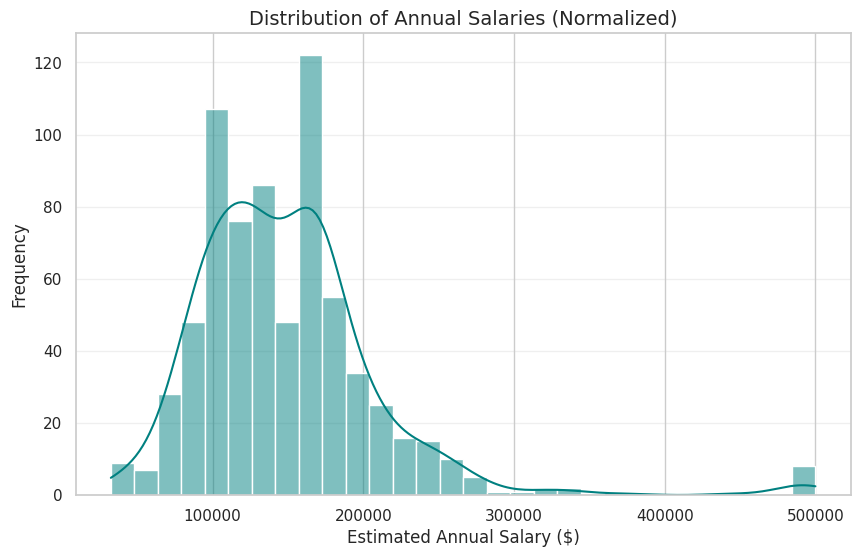

Salary Statistics:
count       707.00
mean     149453.19
std       62830.84
min       32500.00
25%      105999.75
50%      140000.00
75%      172500.00
max      500000.00
Name: Salary, dtype: float64


In [55]:
#Salary Range Analysis
import re
import matplotlib.pyplot as plt
import seaborn as sns

def parse_salary(val):
    if pd.isna(val):
        return None
    # Extract all numbers, removing commas
    nums = [float(n.replace(',', '')) for n in re.findall(r'\d+(?:,\d+)?', str(val))]
    if not nums:
        return None

    # Take average if it's a range, otherwise the single value
    avg_sal = sum(nums) / len(nums)

    # Normalize hourly/monthly to yearly (approximate)
    val_lower = str(val).lower()
    if 'hour' in val_lower:
        avg_sal *= 2080  # 40 hrs * 52 weeks
    elif 'month' in val_lower:
        avg_sal *= 12

    return avg_sal

# Apply parsing and filter out outliers/nulls for plotting
salary_series = self_df['Salary'].apply(parse_salary).dropna()
salary_series = salary_series[salary_series.between(30000, 500000)] # focus on realistic range

plt.figure(figsize=(10, 6))
sns.histplot(salary_series, bins=30, kde=True, color='teal')
plt.title('Distribution of Annual Salaries (Normalized)', fontsize=14)
plt.xlabel('Estimated Annual Salary ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Salary Statistics:")
print(salary_series.describe().round(2))

## 3. Extract skills from job postings

In [56]:
df_main_self = self_df[self_df['Description'].str.strip().ne('')].copy()

print('df_main_self shape:', df_main_self.shape)
df_main_self[['Title', 'Company', 'Location']].head()

df_main_self shape: (755, 10)


,Title,Company,Location
0,ProviderPay Data Analyst,McKesson,"Remote in Columbus, OH"
1,Data Engineer and Analyst,"DevTech Systems, Inc.","Remote in Washington, DC"
2,Senior Technical Data Analyst,VSP Global,Remote
3,Associate Data Analyst (Recent Graduate) Atlanta (Remote Friendly),Greenlight Financial Technology,"Remote in Atlanta, GA"
4,Data Analyst Atlanta (Remote Friendly),Greenlight Financial Technology,"Remote in Atlanta, GA"


In [57]:
# Basic Text Cleaning
def clean_description(text: str) -> str:
    text = str(text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_main_self['description_clean'] = df_main_self['Description'].map(clean_description)
df_main_self['title_clean'] = df_main_self['Title'].str.lower().str.strip()
df_main_self['text_for_skills'] = (df_main_self['Title'].fillna('') + ' ' + df_main_self['description_clean'].fillna('')).str.lower()

df_main_self[['Title', 'description_clean']].head(3)

,Title,description_clean
0,ProviderPay Data Analyst,"ProviderPay Data Analyst Job ID JR0144612 Category Data Management, Information Technology Post Date Mar. 26, 2026 M..."
1,Data Engineer and Analyst,"DevTech is a mission-driven firm specializing in innovative, data-driven solutions that help governments, civil soci..."
2,Senior Technical Data Analyst,"The Senior Technical Data Analyst collaborates with technical staff, business data analysts and subject-matter exper..."


In [58]:
# Manual Seed Skills
seed_skill_dict = {
    'programming': {
        'Python': ['python'],
        'SQL': ['sql', 'postgresql', 'mysql', 'tsql', 'structured query language'],
        'R': ['r', 'r programming', 'rstudio'],
        'Excel': ['excel', 'spreadsheets'],
        'Java': ['java'],
        'Scala': ['scala'],
        'Matlab': ['matlab'],
        'SAS': ['sas'],
        'SPSS': ['spss'],
        'Linux': ['linux', 'unix'],
    },
    'analytics_bi': {
        'Tableau': ['tableau'],
        'Power BI': ['power bi', 'powerbi'],
        'Looker': ['looker', 'looker studio'],
        'Dashboarding': ['dashboard', 'dashboarding'],
        'A/B Testing': ['a/b testing', 'ab testing', 'experiment design'],
        'Business Analysis': ['business analyst', 'business analysis', 'requirements gathering'],
        'Statistical Analysis': ['statistical analysis', 'statistics', 'statistical modeling'],
        'Data Visualization': ['data visualization', 'data visualisation', 'visualization'],
        'Reporting': ['reporting', 'reports', 'report development'],
        'KPIs': ['kpi', 'kpis', 'metrics'],
    },
    'data_engineering': {
        'ETL/ELT': ['etl', 'elt', 'data pipeline', 'pipelines'],
        'Data Warehousing': ['data warehouse', 'data warehousing', 'snowflake', 'redshift', 'bigquery'],
        'Spark': ['spark', 'pyspark'],
        'dbt': ['dbt'],
        'Airflow': ['airflow'],
        'Kafka': ['kafka'],
        'Hadoop': ['hadoop'],
        'Databases': ['database', 'databases', 'database management'],
        'Data Modeling': ['data modeling', 'data modelling', 'schema design'],
        'Big Data': ['big data', 'large-scale data'],
    },
    'ml_ai': {
        'Artificial Intelligence': ['artificial intelligence', 'ai'],
        'Machine Learning': ['machine learning', 'ml '],
        'Deep Learning': ['deep learning'],
        'NLP': ['nlp', 'natural language processing'],
        'Computer Vision': ['computer vision'],
        'LLMs': ['llm', 'large language model', 'generative ai', 'genai'],
        'MLOps': ['mlops'],
        'Optimization': ['optimization', 'optimisation'],
        'Predictive Modeling': ['predictive modeling', 'predictive modelling', 'forecasting'],
    },
    'cloud_tools': {
        'AWS': ['aws', 'amazon web services'],
        'Azure': ['azure'],
        'GCP': ['gcp', 'google cloud'],
        'Docker': ['docker'],
        'Kubernetes': ['kubernetes', 'k8s'],
        'Git': ['git', 'github', 'gitlab'],
    },
    'soft_business': {
        'Communication': ['communication', 'communicate', 'present'],
        'Stakeholder Management': ['stakeholder', 'cross-functional'],
        'Project Management': ['project management', 'project manager'],
        'Leadership': ['leadership', 'mentor', 'mentoring'],
        'Problem Solving': ['problem solving', 'solve complex problems'],
        'Teamwork': ['teamwork', 'team spirit', 'collaboration'],
        'Creativity': ['creativity', 'creative thinking'],
        'Consulting': ['consulting', 'consultant'],
        'Negotiation Skills': ['negotiation', 'negotiation skills'],
        'Agile': ['agile', 'scrum'],
    },
}

seed_rows = []
for category, skill_map in seed_skill_dict.items():
    for skill, aliases in skill_map.items():
        seed_rows.append({
            'skill': skill,
            'category': category,
            'aliases': aliases,
        })

seed_skill_df = pd.DataFrame(seed_rows)
print('Manual seed skills loaded:', len(seed_skill_df))
seed_skill_df.head()

Manual seed skills loaded: 55


,skill,category,aliases
0,Python,programming,[python]
1,SQL,programming,"[sql, postgresql, mysql, tsql, structured query language]"
2,R,programming,"[r, r programming, rstudio]"
3,Excel,programming,"[excel, spreadsheets]"
4,Java,programming,[java]


# 4. API SETUP





In [59]:
# Gemini API Setup
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
GEMINI_MODEL = os.getenv('GEMINI_MODEL', 'gemini-2.5-flash')
MAX_OUTPUT_TOKENS = int(os.getenv('GEMINI_MAX_OUTPUT_TOKENS', '4000'))

try:
    from google.colab import userdata
    if not GEMINI_API_KEY:
        GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
        if GEMINI_API_KEY:
            os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY
except Exception:
    pass

if not GEMINI_API_KEY:
    entered_key = getpass('Paste GEMINI_API_KEY for this session only, or press Enter to skip: ')
    if entered_key.strip():
        GEMINI_API_KEY = entered_key.strip()
        os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY

if GEMINI_API_KEY:
    print('GEMINI_API_KEY loaded for this notebook session.')
else:
    print('GEMINI_API_KEY is missing. Set it before calling the API.')
    print('Example in terminal: export GEMINI_API_KEY="your_api_key_here"')

print('GEMINI_MODEL:', GEMINI_MODEL)
print('MAX_OUTPUT_TOKENS:', MAX_OUTPUT_TOKENS)

Paste GEMINI_API_KEY for this session only, or press Enter to skip: ··········
GEMINI_API_KEY loaded for this notebook session.
GEMINI_MODEL: gemini-2.5-flash
MAX_OUTPUT_TOKENS: 4000


In [60]:
try:
    from google import genai
    from google.genai import types
    from pydantic import BaseModel
except Exception as e:
    print('Google GenAI import failed, installing package...', e)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-U', 'google-genai'])
    from google import genai
    from google.genai import types
    from pydantic import BaseModel

client = genai.Client(api_key=GEMINI_API_KEY) if GEMINI_API_KEY else None

client

## Skills dictionary expansion

In [72]:
# use API for skill dictionary expand
seed_payload = seed_skill_df.to_dict(orient="records")
skill_expansion_prompt = f"""
You are helping build a skill dictionary for a graduate-level assignment.

Starting from the seed skills below, return 60 additional skills that are NOT already in the seed list, relevant to these job families:
- Data Analyst
- Data Scientist
- Data Engineer
- Machine Learning Engineer
- Business Analyst

Requirements:
1. Return JSON only.
2. Return only NEW skills, not the seed skills again.
3. Each item must contain exactly these keys: skill, category, aliases.
4. aliases must be a list of 2-4 lowercase strings.
5. Keep skill names concise, specific, and non-duplicative.
6. Include technical skills, BI/analytics skills, data engineering skills, AI/ML skills, cloud skills, and soft/business skills.
7. Do not include generic degree requirements or vague phrases like "experience".
8. Do not include skills that are already present in the seed list.

Seed skills:
{json.dumps(seed_payload, ensure_ascii=False)}
""".strip()

print(skill_expansion_prompt[:4000])


You are helping build a skill dictionary for a graduate-level assignment.

Starting from the seed skills below, return 60 additional skills that are NOT already in the seed list, relevant to these job families:
- Data Analyst
- Data Scientist
- Data Engineer
- Machine Learning Engineer
- Business Analyst

Requirements:
1. Return JSON only.
2. Return only NEW skills, not the seed skills again.
3. Each item must contain exactly these keys: skill, category, aliases.
4. aliases must be a list of 2-4 lowercase strings.
5. Keep skill names concise, specific, and non-duplicative.
6. Include technical skills, BI/analytics skills, data engineering skills, AI/ML skills, cloud skills, and soft/business skills.
7. Do not include generic degree requirements or vague phrases like "experience".
8. Do not include skills that are already present in the seed list.

Seed skills:
[{"skill": "Python", "category": "programming", "aliases": ["python"]}, {"skill": "SQL", "category": "programming", "aliases": 

In [73]:
class SkillItem(BaseModel):
    skill: str
    category: str
    aliases: list[str]

if client is None:
    print("Client not available. Set GEMINI_API_KEY and install google-genai first.")
else:
    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=skill_expansion_prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=list[SkillItem],
            max_output_tokens=MAX_OUTPUT_TOKENS,
            temperature=0.2,
            thinking_config=types.ThinkingConfig(thinking_budget=0),
        ),
    )

    expanded_skill_text = response.text
    expanded_skill_parsed = response.parsed

    print("Response length:", len(expanded_skill_text))
    print(expanded_skill_text[:4000])

Response length: 7554
[
  {
    "skill": "Julia",
    "category": "programming",
    "aliases": ["julia", "julia language"]
  },
  {
    "skill": "Go",
    "category": "programming",
    "aliases": ["go", "golang"]
  },
  {
    "skill": "C++",
    "category": "programming",
    "aliases": ["c++", "cpp"]
  },
  {
    "skill": "VBA",
    "category": "programming",
    "aliases": ["vba", "visual basic for applications"]
  },
  {
    "skill": "SAS Programming",
    "category": "programming",
    "aliases": ["sas programming", "sas macro"]
  },
  {
    "skill": "Stata",
    "category": "programming",
    "aliases": ["stata", "stata programming"]
  },
  {
    "skill": "Qlik Sense",
    "category": "analytics_bi",
    "aliases": ["qlik sense", "qliksense"]
  },
  {
    "skill": "MicroStrategy",
    "category": "analytics_bi",
    "aliases": ["microstrategy", "mstr"]
  },
  {
    "skill": "SAP BusinessObjects",
    "category": "analytics_bi",
    "aliases": ["sap businessobjects", "businessobj

In [74]:
# Parse the model output after the previous cell succeeds.

import ast
import json
import pandas as pd

expanded_skill_df = None

def strip_json_fences(text: str) -> str:
    text = str(text).strip()
    if text.startswith("```json"):
        text = text[7:]
    elif text.startswith("```"):
        text = text[3:]
    if text.endswith("```"):
        text = text[:-3]
    return text.strip()

def extract_json_array(text: str) -> str:
    text = strip_json_fences(text)
    start = text.find("[")
    end = text.rfind("]")
    if start != -1 and end != -1 and end > start:
        return text[start:end + 1]
    return text

def parse_aliases(value):
    if isinstance(value, list):
        return [str(x).strip().lower() for x in value if str(x).strip()]
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(x).strip().lower() for x in parsed if str(x).strip()]
        except Exception:
            pass
        return [x.strip().lower() for x in value.split(",") if x.strip()]
    return []

def normalize_skill_records(records):
    cleaned = []
    for item in records:
        if hasattr(item, "model_dump"):
            item = item.model_dump()
        elif not isinstance(item, dict):
            item = dict(item)

        skill = str(item.get("skill", "")).strip()
        category = str(item.get("category", "")).strip()
        aliases = parse_aliases(item.get("aliases", []))

        if skill and category and aliases:
            cleaned.append({
                "skill": skill,
                "category": category,
                "aliases": aliases,
            })

    return cleaned

try:
    if "expanded_skill_parsed" in globals() and expanded_skill_parsed is not None:
        expanded_skill_json = normalize_skill_records(expanded_skill_parsed)
    else:
        candidate_text = extract_json_array(expanded_skill_text)
        try:
            expanded_skill_json = normalize_skill_records(json.loads(candidate_text))
        except json.JSONDecodeError as json_err:
            expanded_skill_json = normalize_skill_records(ast.literal_eval(candidate_text))

    expanded_skill_df = pd.DataFrame(expanded_skill_json)
    expanded_skill_df["skill_key"] = expanded_skill_df["skill"].str.lower().str.strip()
    expanded_skill_df = expanded_skill_df.drop_duplicates(subset=["skill_key"]).drop(columns=["skill_key"]).reset_index(drop=True)

    display(expanded_skill_df.head())
    print("Expanded skills extracted:", len(expanded_skill_df))

except Exception as e:
    print("Could not parse expanded_skill_text as JSON:", e)

,skill,category,aliases
0,Julia,programming,"[julia, julia language]"
1,Go,programming,"[go, golang]"
2,C++,programming,"[c++, cpp]"
3,VBA,programming,"[vba, visual basic for applications]"
4,SAS Programming,programming,"[sas programming, sas macro]"


Expanded skills extracted: 60


In [75]:
# Combine seed skills and expanded skills into final skill dictionary
skill_df = seed_skill_df.copy()

if 'expanded_skill_df' in globals() and expanded_skill_df is not None:
    skill_df = pd.concat([seed_skill_df, expanded_skill_df], ignore_index=True)
    skill_df["skill_key"] = skill_df["skill"].astype(str).str.lower().str.strip()
    skill_df = (
        skill_df
        .drop_duplicates(subset=["skill_key"], keep="last")
        .drop(columns=["skill_key"])
        .reset_index(drop=True)
    )

print("Final skill dictionary size:", len(skill_df))
display(skill_df.head())

Final skill dictionary size: 115


,skill,category,aliases
0,Python,programming,[python]
1,SQL,programming,"[sql, postgresql, mysql, tsql, structured query language]"
2,R,programming,"[r, r programming, rstudio]"
3,Excel,programming,"[excel, spreadsheets]"
4,Java,programming,[java]


## N-Gram

In [91]:
# Prepare N-gram Vocabulary Mapping with Collision Check
alias_to_skill = {}

# Add all aliases (lowercase and stripped)
for _, row in skill_df.iterrows():
    base_skill = row['skill']
    aliases = [str(a).lower().strip() for a in row['aliases']]
    for alias in aliases:
        if alias:
            alias_to_skill[alias] = base_skill

# Ensure the base skill name itself always maps to itself
for _, row in skill_df.iterrows():
    name_lower = str(row['skill']).lower().strip()
    alias_to_skill[name_lower] = row['skill']

# Our N-gram vocabulary is the exact list of phrases we care about
vocabulary = list(alias_to_skill.keys())

# Find the maximum n-gram length needed
max_ngram_len = max(len(v.split()) for v in vocabulary) if vocabulary else 1

print(f"Total base skills defined: {len(skill_df)}")
print(f"Total unique n-gram phrases in vocabulary: {len(vocabulary)}")
print(f"Maximum N-gram length required: {max_ngram_len}")

Total base skills defined: 115
Total unique n-gram phrases in vocabulary: 254
Maximum N-gram length required: 4


In [92]:
import warnings
from sklearn.feature_extraction.text import CountVectorizer

# Suppress DataFrame fragmentation warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# Extract Skills using N-grams
def extract_skill_matrix_ngram(df_input: pd.DataFrame, vocab_mapping: dict, max_n: int) -> pd.DataFrame:
    vocab_keys = list(vocab_mapping.keys())

    vectorizer = CountVectorizer(
        ngram_range=(1, max_n),
        vocabulary=vocab_keys,
        lowercase=True,
        token_pattern=r"(?u)[a-zA-Z0-9\+\#\/\-]+"
    )

    # Extract n-grams from the cleaned text
    X = vectorizer.fit_transform(df_input['text_for_skills'])
    ngram_counts = pd.DataFrame(X.toarray(), columns=vocab_keys)

    # Initialize the result dataframe with metadata
    meta_cols = ['Title', 'Company', 'Location', 'dataset_source', 'Links']
    result_df = df_input[meta_cols].copy().reset_index(drop=True)

    # Aggregate n-gram phrase counts back into their parent base skills
    unique_skills = sorted(list(set(vocab_mapping.values())))
    for skill in unique_skills:
        result_df[skill] = 0

    for alias, base_skill in vocab_mapping.items():
        result_df[base_skill] += ngram_counts[alias]

    # Convert frequencies to binary presence
    for skill in unique_skills:
        result_df[skill] = (result_df[skill] > 0).astype(int)

    return result_df

# Generate the matrix using the fixed vocabulary from the previous cell
skill_matrix_self = extract_skill_matrix_ngram(df_main_self, alias_to_skill, max_ngram_len)

# Re-define skill_columns
skill_columns = [s for s in skill_df['skill'].unique() if s in skill_matrix_self.columns]

print('skill_matrix_self shape:', skill_matrix_self.shape)
print('Total unique skills captured:', len(skill_columns))
display(skill_matrix_self.head(3))

skill_matrix_self shape: (755, 120)
Total unique skills captured: 115


,Title,Company,Location,dataset_source,Links,A/B Testing,AWS,Adaptability,Agile,Airflow,Ansible,Artificial Intelligence,Azure,Big Data,Business Analysis,C++,CI/CD,Causal Inference,Client Management,Cloud Computing,Cloud Data Platforms,Communication,Computer Vision,Conflict Resolution,Consulting,Creativity,Critical Thinking,Cross-functional Collaboration,Dashboarding,Data Architecture,Data Governance,Data Integration,Data Lakes,Data Modeling,Data Pipelines,Data Quality,Data Security,Data Security & Privacy,Data Storytelling,Data Visualization,Data Warehousing,Databases,Decision Making,Deep Learning,Docker,Documentation,ETL/ELT,Econometrics,Excel,Experimentation,Feature Engineering,Financial Modeling,GCP,Generative AI,Git,Go,Google Analytics,Hadoop,Java,Julia,KPIs,Kafka,Keras,Kubernetes,LLMs,Leadership,Linux,Looker,MLOps,Machine Learning,Market Research,Matlab,Mentorship,MicroStrategy,Model Deployment,Model Evaluation,Model Interpretability,NLP,Negotiation Skills,Neural Networks,NoSQL,Optimization,Power BI,Predictive Modeling,Problem Solving,Process Improvement,Project Management,PyTorch,Python,Qlik Sense,R,Reinforcement Learning,Reporting,Requirements Gathering,Risk Management,SAP BusinessObjects,SAS,SAS Programming,SPSS,SQL,Scala,Scikit-learn,Shell Scripting,Spark,Stakeholder Management,Stata,Statistical Analysis,Strategic Thinking,Stream Processing,Tableau,Teamwork,TensorFlow,Terraform,Time Series Analysis,User Experience (UX),VBA,Version Control,Web Analytics,XGBoost,dbt
0,ProviderPay Data Analyst,McKesson,"Remote in Columbus, OH",self_scraped,https://www.indeed.com/rc/clk?jk=5242412176574f25&bb=acxTV76izZ045vb_gM0TWVu1DcNWJ6v1doXsDZKpkZDPTcoHHXpFbJOEwcl47YU...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
1,Data Engineer and Analyst,"DevTech Systems, Inc.","Remote in Washington, DC",self_scraped,https://www.indeed.com/rc/clk?jk=13b43438c67b8907&bb=acxTV76izZ045vb_gM0TWUu9K24W4t7j9dmz-vxGoMHJpt2n_wdBlZjPBiC1oXC...,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,1,0,1,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,Senior Technical Data Analyst,VSP Global,Remote,self_scraped,https://www.indeed.com/rc/clk?jk=5fcb9b1f9fae6de2&bb=acxTV76izZ045vb_gM0TWfEoF6qhxd9fSpmS2UwJD6Y6MXXrCOSHj25xyt5z5pm...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0


In [93]:
#Simple Feature Summaries
skill_columns = [c for c in skill_matrix_self.columns if c not in ['Title', 'Company', 'Location', 'dataset_source', 'Links']]
skill_counts = skill_matrix_self[skill_columns].sum().sort_values(ascending=False)
skill_counts.head(20)

,0
Communication,518
Python,450
SQL,410
Artificial Intelligence,366
ETL/ELT,362
Machine Learning,349
Teamwork,297
Reporting,293
Leadership,284
Stakeholder Management,255


In [147]:
# Identify and remove zero-frequency skills from skill_columns
zero_freq_skills = [s for s in skill_columns if skill_matrix_self[s].sum() == 0]

print(f"Skills with zero frequency: {len(zero_freq_skills)}")
if zero_freq_skills:
    print(zero_freq_skills)
    # Remove zero-frequency skills from skill_columns
    skill_columns = [s for s in skill_columns if s not in zero_freq_skills]
    print(f"\nUpdated skill_columns: {len(skill_columns)} skills")
else:
    print("No zero-frequency skills found.")

Skills with zero frequency: 1
['SAP BusinessObjects']

Updated skill_columns: 114 skills


# Visualization

/tmp/ipykernel_5224/2623500726.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')


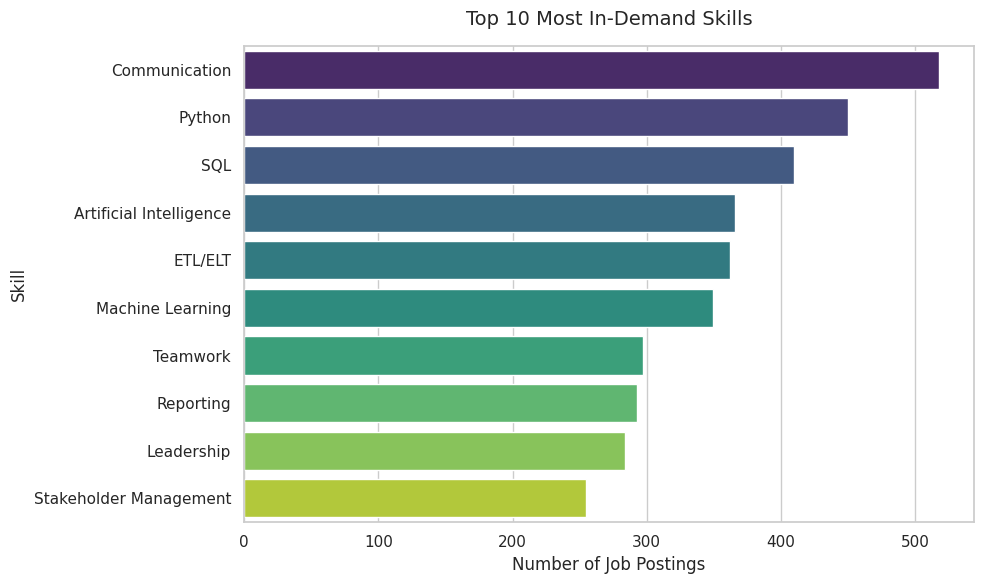

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')

# VISUALIZATION 1: Top 10 Overall Skills
plt.figure(figsize=(10, 6))
top_skills = skill_matrix_self[skill_columns].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_skills.values, y=top_skills.index, palette='viridis')
plt.title('Top 10 Most In-Demand Skills', fontsize=14, pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()



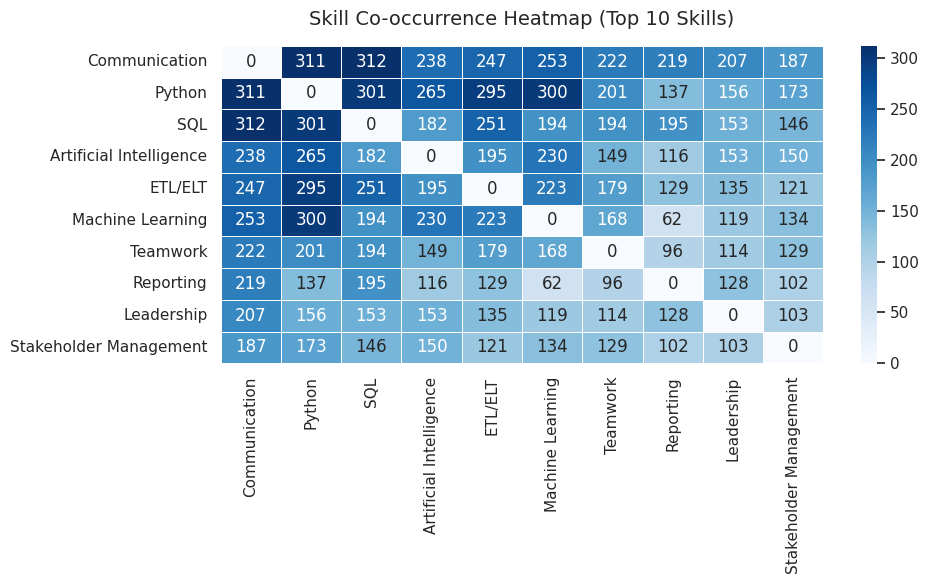

In [149]:
# VISUALIZATION 2: Skill Co-occurrence Heatmap
# Get the top 10 skills again for a clean matrix
top_10_skill_names = top_skills.index.tolist()
co_occurrence = skill_matrix_self[top_10_skill_names].T.dot(skill_matrix_self[top_10_skill_names])


np.fill_diagonal(co_occurrence.values, 0)

sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.title('Skill Co-occurrence Heatmap (Top 10 Skills)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_5224/1749953063.py:3: SyntaxWarning: invalid escape sequence '\.'
  is_senior = skill_matrix_self['Title'].str.contains('senior|sr\.|lead|principal', case=False, na=False)
/tmp/ipykernel_5224/1749953063.py:4: SyntaxWarning: invalid escape sequence '\.'
  is_junior = skill_matrix_self['Title'].str.contains('junior|jr\.|entry|associate|graduate', case=False, na=False)


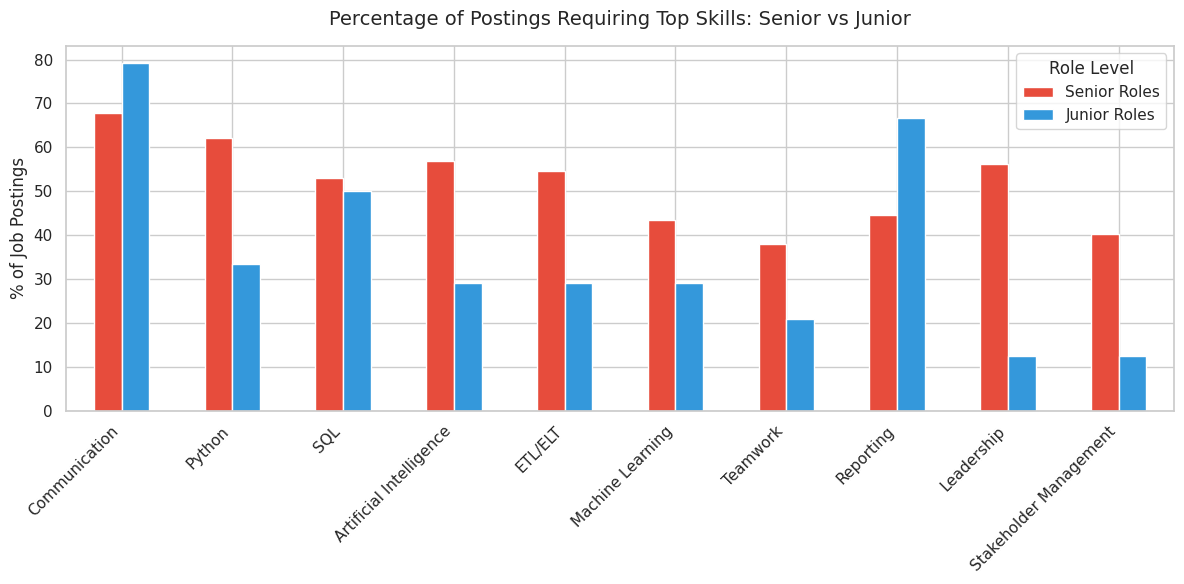

In [150]:
# VISUALIZATION 3: Skills by Seniority (Engineered Feature)
# Create flags for seniority based on the job title
is_senior = skill_matrix_self['Title'].str.contains('senior|sr\.|lead|principal', case=False, na=False)
is_junior = skill_matrix_self['Title'].str.contains('junior|jr\.|entry|associate|graduate', case=False, na=False)

senior_skills = skill_matrix_self.loc[is_senior, top_10_skill_names].mean() * 100
junior_skills = skill_matrix_self.loc[is_junior, top_10_skill_names].mean() * 100

seniority_df = pd.DataFrame({'Senior Roles': senior_skills, 'Junior Roles': junior_skills})

ax = seniority_df.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#3498db'])
plt.title('Percentage of Postings Requiring Top Skills: Senior vs Junior', fontsize=14, pad=15)
plt.ylabel('% of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Role Level')
plt.tight_layout()
plt.show()



/tmp/ipykernel_5224/1819851717.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma')


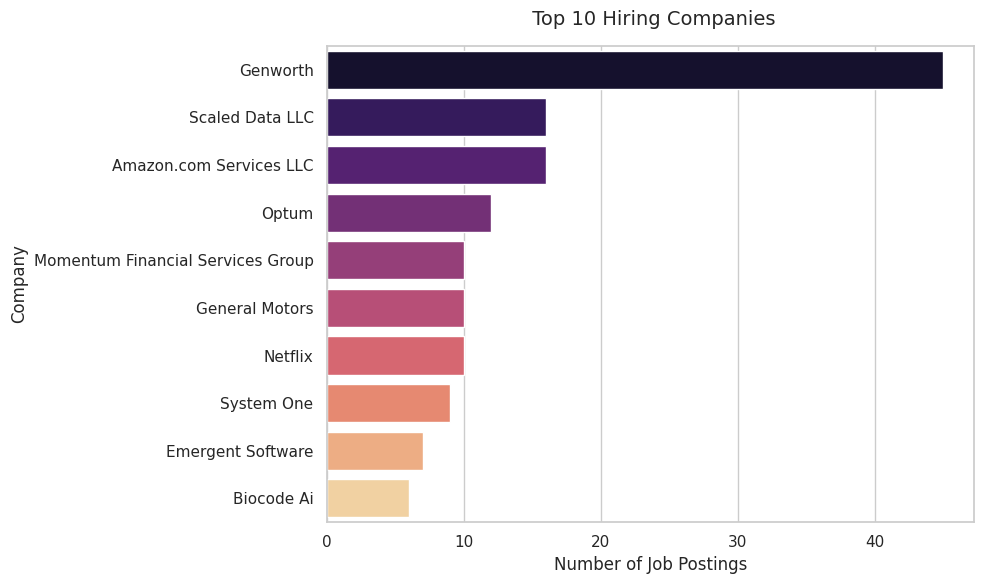

In [151]:
# VISUALIZATION 4: Top 10 Hiring Companies
plt.figure(figsize=(10, 6))
top_companies = df_main_self['Company'].value_counts().head(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma')
plt.title(' Top 10 Hiring Companies', fontsize=14, pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


/tmp/ipykernel_5224/1487630830.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='cubehelix')


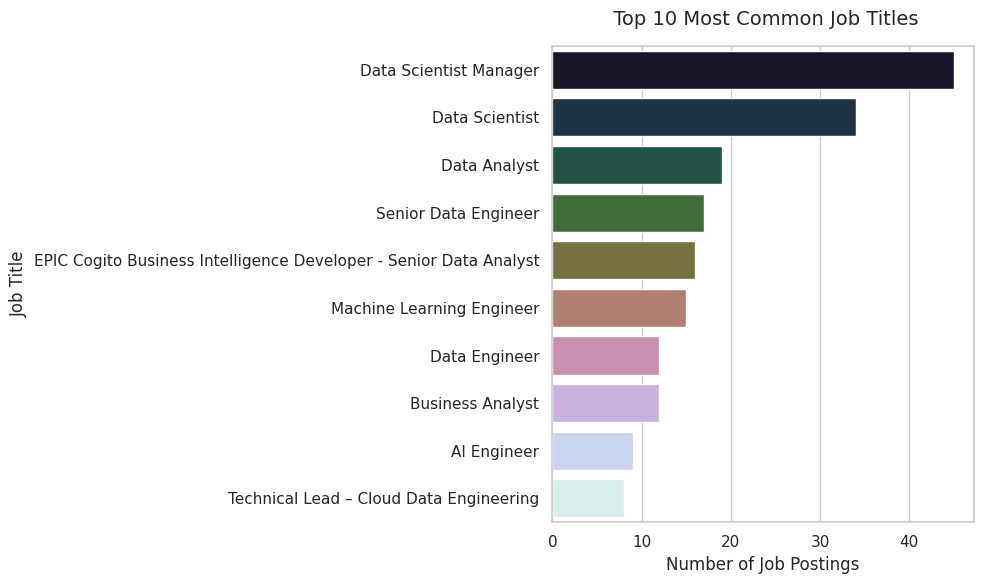

In [152]:
# Visualization 5: Most Common Job Titles
# A quick look at the most frequent exact job titles.

plt.figure(figsize=(10, 6))
top_titles = df_main_self['Title'].value_counts().head(10)
sns.barplot(x=top_titles.values, y=top_titles.index, palette='cubehelix')
plt.title(' Top 10 Most Common Job Titles', fontsize=14, pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()


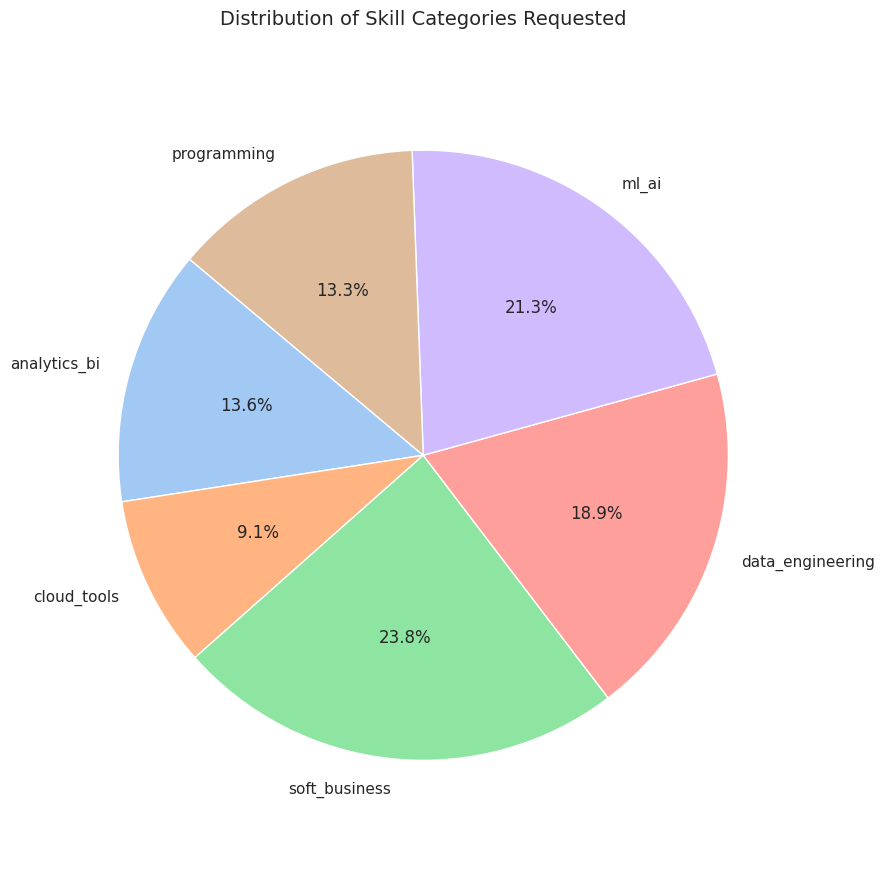

In [153]:
# VISUALIZATION 6: Skill Categories Breakdown
plt.figure(figsize=(9, 9))

# Create a mapping from skill name to category using our existing skill_df
skill_to_cat = dict(zip(skill_df['skill'], skill_df['category']))

category_counts = {}
for skill in skill_columns:
    cat = skill_to_cat.get(skill, 'unknown')
    # Add the total occurrences of this skill to its category from the matrix
    category_counts[cat] = category_counts.get(cat, 0) + skill_matrix_self[skill].sum()

# Remove 'unknown' if it's empty or zero
if 'unknown' in category_counts and category_counts['unknown'] == 0:
    del category_counts['unknown']

plt.pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Skill Categories Requested', fontsize=14, pad=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Feature Engineering

In [154]:
import re
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_distances

# Parse metadata (salary, seniority, remote/location flags)
def extract_salary(text):
    text = str(text).lower().replace(',', '')
    #k notation
    k_matches = re.findall(r'\b(\d+(?:\.\d+)?)k\b', text)
    if k_matches:
        nums = [float(n) * 1000 for n in k_matches]
    else:
        nums = [float(n) for n in re.findall(r'\b\d+(?:\.\d+)?\b', text)]

    if not nums:
        return np.nan
    if 'hour' in text or 'hr' in text:
        nums = [n * 2000 for n in nums]

    avg_sal = np.mean(nums)
    # Keep it only if it makes sense as an annual salary
    return avg_sal if 20000 < avg_sal < 400000 else np.nan

df_main_self['salary_parsed'] = df_main_self['Salary'].apply(extract_salary)

# Flag seniority levels using regex (using raw strings to avoid escape warnings)
df_main_self['is_senior'] = df_main_self['Title'].str.contains(r'senior|sr\.|lead|principal|director|manager', case=False, na=False).astype(int)
df_main_self['is_junior'] = df_main_self['Title'].str.contains(r'junior|jr\.|entry|associate|graduate|intern', case=False, na=False).astype(int)

# Flag locations
df_main_self['is_remote'] = df_main_self['Location'].str.contains('remote', case=False, na=False).astype(int)
df_main_self['is_canada'] = df_main_self['Location'].str.contains(r'canada|toronto|vancouver|montreal|calgary|ottawa|\bon\b|\bbc\b|\bab\b|\bqc\b', case=False, na=False).astype(int)

display(df_main_self[['Title', 'Location', 'Salary', 'salary_parsed', 'is_senior', 'is_junior']].head())


,Title,Location,Salary,salary_parsed,is_senior,is_junior
0,ProviderPay Data Analyst,"Remote in Columbus, OH",$34 per hour,68000.0,0,0
1,Data Engineer and Analyst,"Remote in Washington, DC",NaN,NaN,0,0
2,Senior Technical Data Analyst,Remote,"$63,000 - $108,675 a year",85837.5,1,0
3,Associate Data Analyst (Recent Graduate) Atlanta (Remote Friendly),"Remote in Atlanta, GA","$65,000 - $90,000 a year",77500.0,0,1
4,Data Analyst Atlanta (Remote Friendly),"Remote in Atlanta, GA","$125,000 - $145,000 a year",135000.0,0,0


In [155]:
# Build the skill feature table
n_jobs = len(df_main_self)
global_avg_sal = df_main_self['salary_parsed'].mean()

features = []

for skill in skill_columns:
    mask = skill_matrix_self[skill] == 1
    if not mask.any():
        continue # Skip if skill never appears in the data

    df_with = df_main_self[mask.values]
    df_without = df_main_self[~mask.values]
    freq = mask.sum()

    # Handle salaries with fallback to global average if missing
    sal_with = df_with['salary_parsed'].mean()
    sal_without = df_without['salary_parsed'].mean()

    sal_with = sal_with if pd.notna(sal_with) else global_avg_sal
    sal_without = sal_without if pd.notna(sal_without) else global_avg_sal

    features.append({
        'skill': skill,
        'frequency': freq,
        'skill_share': freq / n_jobs,
        'avg_salary': sal_with,
        'salary_premium': sal_with - sal_without,
        'junior_share': df_with['is_junior'].mean(),
        'senior_share': df_with['is_senior'].mean(),
        'remote_share': df_with['is_remote'].mean(),
        'canada_share': df_with['is_canada'].mean(),
        'location_diversity': df_with['Location'].nunique(),
        'company_diversity': df_with['Company'].nunique(),
        'python_cooccurrence': skill_matrix_self.loc[mask, 'Python'].sum() / freq,
        'sql_cooccurrence': skill_matrix_self.loc[mask, 'SQL'].sum() / freq
    })

skill_features = pd.DataFrame(features).set_index('skill').fillna(0)

print(f"Total skills in matrix: {len(skill_columns)}")
print(f"Feature table shape: {skill_features.shape}")

display(skill_features.head())

# Scale features for K-Means
scaler = StandardScaler()
skill_features_scaled = pd.DataFrame(
    scaler.fit_transform(skill_features),
    index=skill_features.index,
    columns=skill_features.columns
)

Total skills in matrix: 114
Feature table shape: (114, 12)


,frequency,skill_share,avg_salary,salary_premium,junior_share,senior_share,remote_share,canada_share,location_diversity,company_diversity,python_cooccurrence,sql_cooccurrence
skill,,,,,,,,,,,,
A/B Testing,25,0.033113,160047.976190,15076.560199,0.000000,0.320000,0.760000,0.040000,14,23,0.800000,0.680000
AWS,179,0.237086,161468.698413,21026.973477,0.005587,0.418994,0.759777,0.117318,73,141,0.826816,0.541899
Adaptability,222,0.294040,140044.282353,-8272.700256,0.018018,0.396396,0.801802,0.081081,70,146,0.590090,0.558559
Agile,113,0.149669,126783.750000,-21470.633592,0.035398,0.415929,0.876106,0.088496,50,92,0.575221,0.610619
Airflow,45,0.059603,159786.953125,15141.602193,0.022222,0.444444,0.844444,0.044444,22,38,0.955556,0.844444


# Hierarchical Clustering

In [156]:
# Distance Matrix for Hierarchical Clustering

presence_matrix = skill_matrix_self[skill_columns].T
dist_matrix = cosine_distances(presence_matrix)

distance_df = pd.DataFrame(dist_matrix, index=skill_columns, columns=skill_columns)

print(f"Distance matrix shape: {distance_df.shape}")
print("Distance from Python (top 5 closest skills):")
# Exclude Python itself from the display
display(distance_df['Python'].sort_values().head(6)[1:])


Distance matrix shape: (114, 114)
Distance from Python (top 5 closest skills):


,Python
Machine Learning,0.242989
ETL/ELT,0.269094
SQL,0.299242
Artificial Intelligence,0.347021
Communication,0.355847


In [157]:
# Hierarchical Clustering

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# ensure the distance matrix is perfectly symmetric and diagonal is exactly 0
dist_matrix_sym = (dist_matrix + dist_matrix.T) / 2.0
np.fill_diagonal(dist_matrix_sym, 0.0)

condensed_dist = squareform(dist_matrix_sym)

# Perform hierarchical/agglomerative clustering
Z = linkage(condensed_dist, method='average')


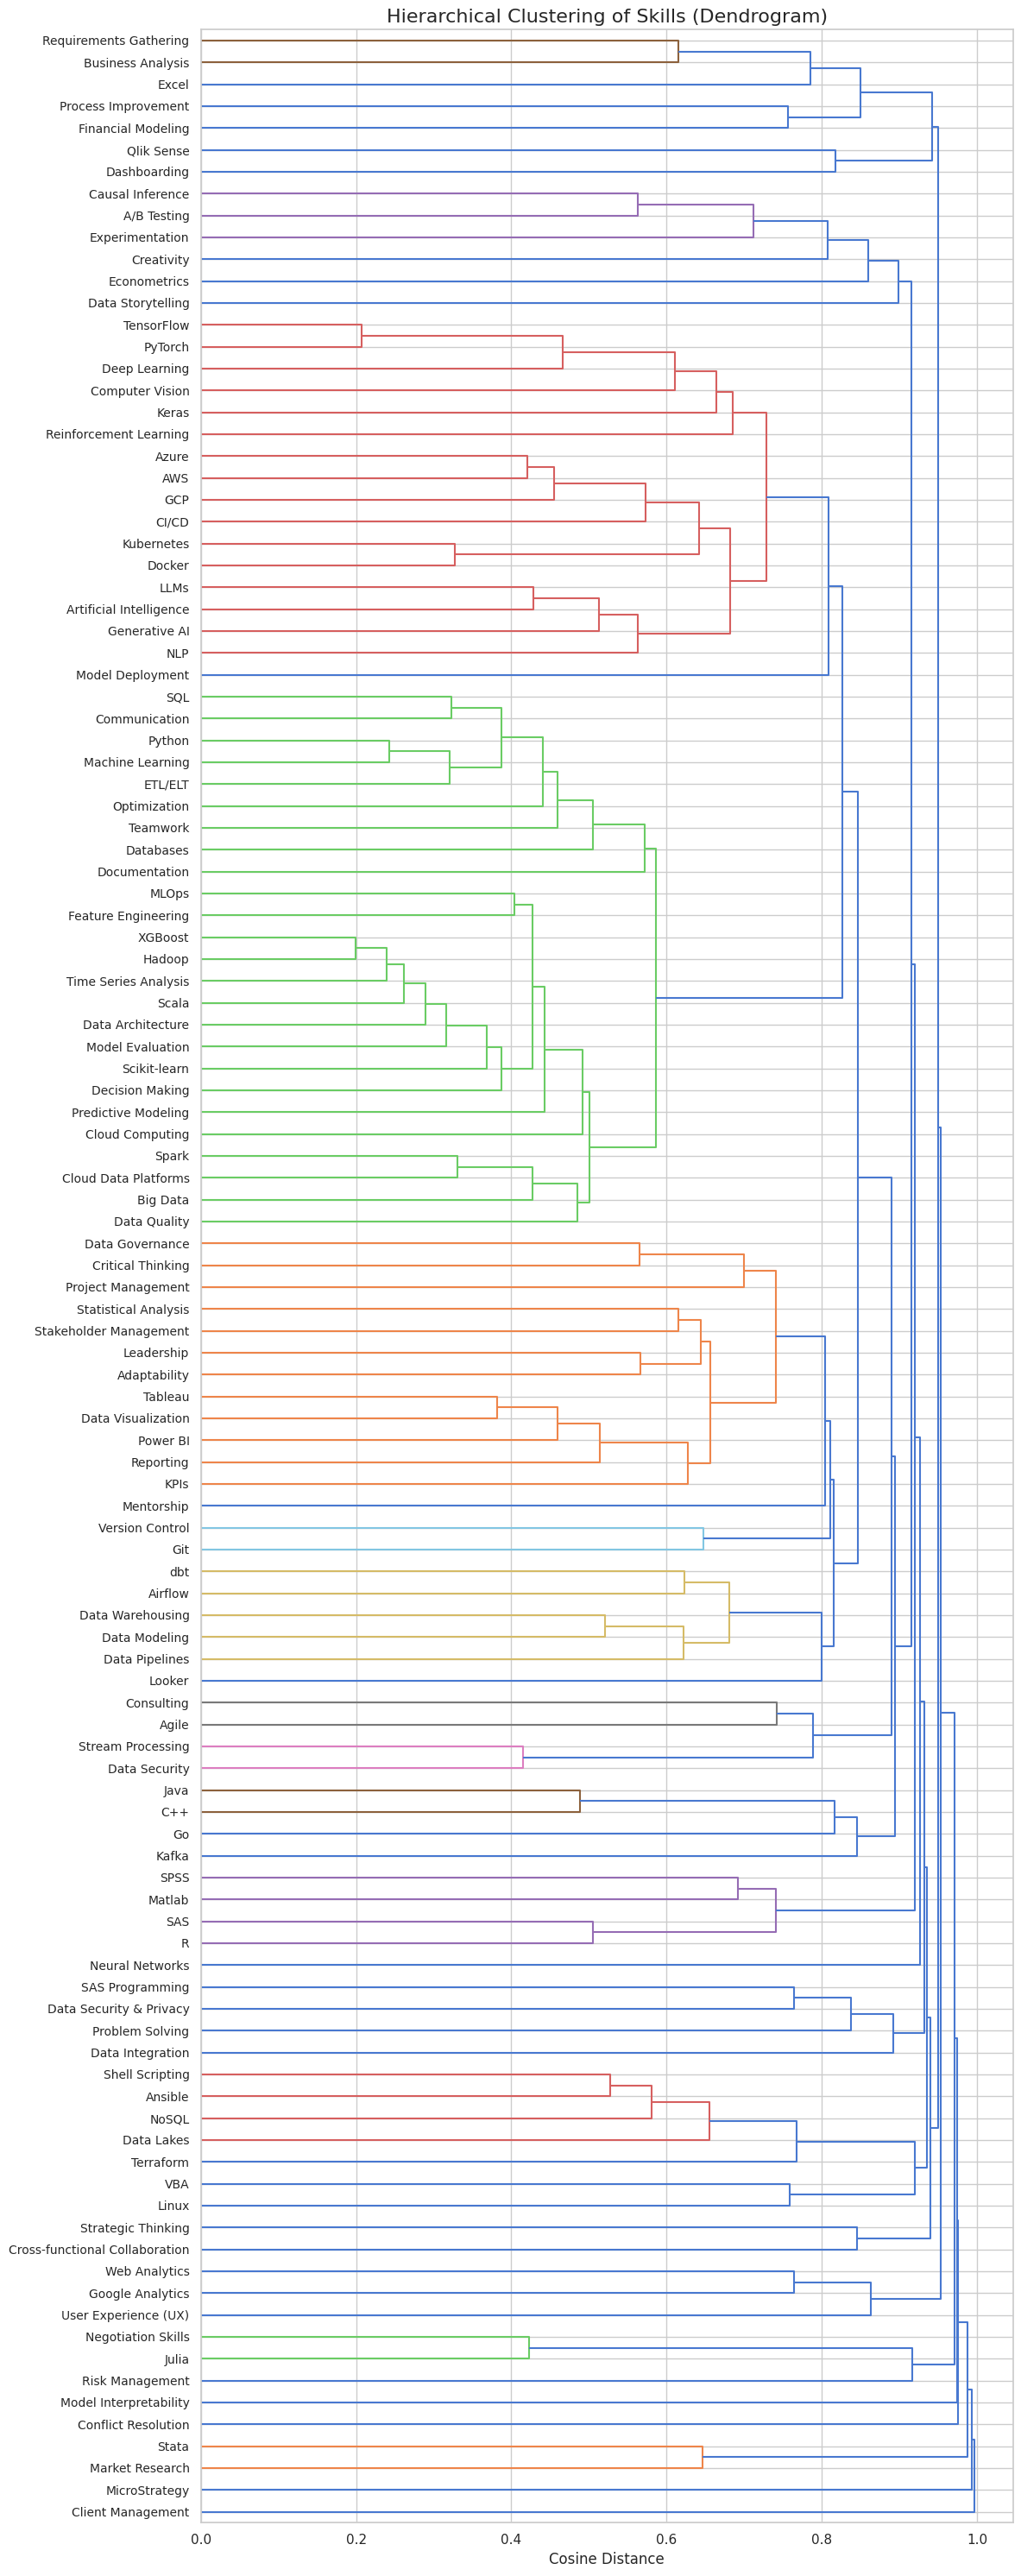

In [158]:
# Create the dendrogram
plt.figure(figsize=(12, 30))

dendrogram(
    Z,
    labels=skill_columns,
    orientation='right',
    leaf_font_size=10,
    color_threshold=0.75
)
plt.title('Hierarchical Clustering of Skills (Dendrogram)', fontsize=16)
plt.xlabel('Cosine Distance', fontsize=12)
plt.tight_layout()
plt.show()

In [159]:
hier_labels = fcluster(Z, t=10, criterion='maxclust')
skill_hier = pd.Series(hier_labels, index=skill_columns)

for c in sorted(skill_hier.unique()):
    skills = skill_hier[skill_hier == c].index.tolist()
    print(f"Course {c} ({len(skills)} skills): {', '.join(skills)}")

Course 1 (2 skills): Market Research, Stata
Course 2 (3 skills): Julia, Negotiation Skills, Risk Management
Course 3 (3 skills): Google Analytics, User Experience (UX), Web Analytics
Course 4 (95 skills): A/B Testing, AWS, Adaptability, Agile, Airflow, Ansible, Artificial Intelligence, Azure, Big Data, C++, CI/CD, Causal Inference, Cloud Computing, Cloud Data Platforms, Communication, Computer Vision, Consulting, Creativity, Critical Thinking, Cross-functional Collaboration, Data Architecture, Data Governance, Data Integration, Data Lakes, Data Modeling, Data Pipelines, Data Quality, Data Security, Data Security & Privacy, Data Storytelling, Data Visualization, Data Warehousing, Databases, Decision Making, Deep Learning, Docker, Documentation, ETL/ELT, Econometrics, Experimentation, Feature Engineering, GCP, Generative AI, Git, Go, Hadoop, Java, KPIs, Kafka, Keras, Kubernetes, LLMs, Leadership, Linux, Looker, MLOps, Machine Learning, Matlab, Mentorship, Model Deployment, Model Evaluati

In [202]:
manual_courses_h = {
    'Programming Foundations for Data Science': [
        'Python', 'SQL', 'R', 'Java', 'Scala', 'C++', 'Go',
        'Shell Scripting', 'Git', 'Version Control', 'Linux', 'VBA', 'Julia',
    ],
    'Data Engineering and Database Systems': [
        'ETL/ELT', 'Data Warehousing', 'Data Modeling', 'Databases',
        'Airflow', 'dbt', 'Spark', 'Kafka', 'Hadoop', 'Big Data',
        'NoSQL', 'Data Lakes', 'Stream Processing', 'Data Pipelines',
        'Data Integration', 'Data Architecture',
    ],
    'Data Visualization and Business Intelligence': [
        'Tableau', 'Power BI', 'Looker', 'Dashboarding', 'Reporting',
        'KPIs', 'Data Visualization', 'Data Storytelling', 'Qlik Sense',
        'MicroStrategy', 'Excel', 'Google Analytics', 'Web Analytics',
    ],
    'Statistical Analysis and Experimentation': [
        'Statistical Analysis', 'A/B Testing', 'Experimentation',
        'Econometrics', 'Causal Inference', 'Time Series Analysis',
        'Matlab', 'SPSS', 'SAS', 'SAS Programming', 'Stata',
    ],
    'Machine Learning and Predictive Modeling': [
        'Machine Learning', 'Scikit-learn', 'Feature Engineering',
        'Model Evaluation', 'Predictive Modeling', 'Optimization',
        'MLOps', 'Model Deployment', 'XGBoost', 'Neural Networks',
        'Model Interpretability',
    ],
    'Deep Learning and Applied AI': [
        'Deep Learning', 'NLP', 'Computer Vision', 'LLMs',
        'Artificial Intelligence', 'TensorFlow', 'PyTorch', 'Keras',
        'Reinforcement Learning', 'Generative AI',
    ],
    'Cloud and DevOps for Data Systems': [
        'AWS', 'Azure', 'GCP', 'Docker', 'Kubernetes', 'CI/CD',
        'Terraform', 'Ansible', 'Cloud Computing', 'Cloud Data Platforms',
    ],
    'Data Governance, Security, and Quality': [
        'Data Governance', 'Data Quality', 'Data Security',
        'Data Security & Privacy', 'Requirements Gathering',
        'Documentation', 'Risk Management',
    ],
    'Business Analysis and Strategy': [
        'Business Analysis', 'Consulting', 'Agile', 'Strategic Thinking',
        'Decision Making', 'Process Improvement', 'Negotiation Skills',
        'Financial Modeling', 'Market Research', 'Client Management',
        'User Experience (UX)',
    ],
    'Professional Skills for Data Science and Analytics': [
        'Communication', 'Stakeholder Management', 'Leadership',
        'Project Management', 'Problem Solving', 'Teamwork', 'Creativity',
        'Critical Thinking', 'Adaptability', 'Mentorship',
        'Cross-functional Collaboration', 'Conflict Resolution',
    ],
}

# Verify
all_assigned = [s for skills in manual_courses_h.values() for s in skills]
print(f"Total assigned: {len(all_assigned)}")
print(f"Unique assigned: {len(set(all_assigned))}")
print(f"Total skills: {len(skill_columns)}")

missing = set(skill_columns) - set(all_assigned)
if missing:
    print(f"Missing skills: {missing}")

duplicates = [s for s in all_assigned if all_assigned.count(s) > 1]
if duplicates:
    print(f"Duplicates: {set(duplicates)}")

Total assigned: 114
Unique assigned: 114
Total skills: 114


In [203]:
for course, skills in manual_courses_h.items():
    print(f"\n{course} ({len(skills)} skills):")
    print(', '.join(skills))


Programming Foundations for Data Science (13 skills):
Python, SQL, R, Java, Scala, C++, Go, Shell Scripting, Git, Version Control, Linux, VBA, Julia

Data Engineering and Database Systems (16 skills):
ETL/ELT, Data Warehousing, Data Modeling, Databases, Airflow, dbt, Spark, Kafka, Hadoop, Big Data, NoSQL, Data Lakes, Stream Processing, Data Pipelines, Data Integration, Data Architecture

Data Visualization and Business Intelligence (13 skills):
Tableau, Power BI, Looker, Dashboarding, Reporting, KPIs, Data Visualization, Data Storytelling, Qlik Sense, MicroStrategy, Excel, Google Analytics, Web Analytics

Statistical Analysis and Experimentation (11 skills):
Statistical Analysis, A/B Testing, Experimentation, Econometrics, Causal Inference, Time Series Analysis, Matlab, SPSS, SAS, SAS Programming, Stata

Machine Learning and Predictive Modeling (11 skills):
Machine Learning, Scikit-learn, Feature Engineering, Model Evaluation, Predictive Modeling, Optimization, MLOps, Model Deployment

In [204]:
manual_labels = np.zeros(len(skill_columns), dtype=int)
for i, (course, skills) in enumerate(manual_courses_h.items()):
    for skill in skills:
        idx = skill_columns.index(skill)
        manual_labels[idx] = i

sil = silhouette_score(
    skill_matrix_self[skill_columns].T,
    manual_labels,
    metric='cosine'
)

print(f"Silhouette Score (after manual adjustment): {sil:.4f}")

Silhouette Score (after manual adjustment): 0.0033


# K-Means





In [164]:
# K-Means: Find Optimal K (Elbow & Silhouette)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(skill_features_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(skill_features_scaled, labels))

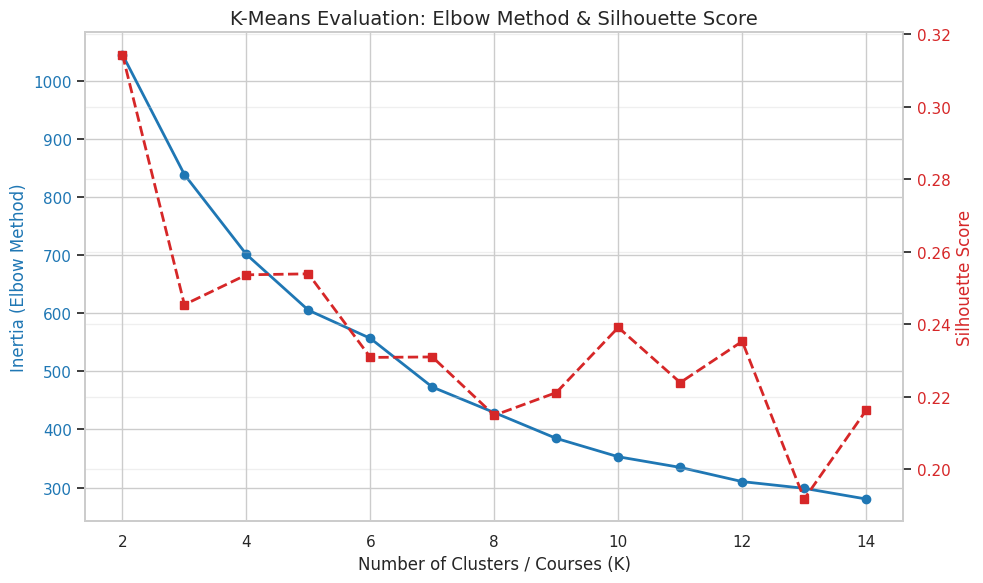

In [165]:
# Elbow & Silhouette Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters / Courses (K)', fontsize=12)
ax1.set_ylabel('Inertia (Elbow Method)', color=color, fontsize=12)
ax1.plot(K_range, inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(K_range, sil_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Evaluation: Elbow Method & Silhouette Score', fontsize=14)
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [205]:
# Apply final K-means with optimal K
OPTIMAL_K = 10
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
skill_features['Course_Cluster'] = kmeans_final.fit_predict(skill_features_scaled)

for c in range(OPTIMAL_K):
    skills = skill_features[skill_features['Course_Cluster'] == c].index.tolist()
    print(f"Course {c} ({len(skills)} skills): {', '.join(skills)}")

Course 0 (10 skills): Business Analysis, Client Management, Data Storytelling, Excel, Market Research, MicroStrategy, Problem Solving, Process Improvement, Requirements Gathering, SAS Programming
Course 1 (24 skills): C++, Computer Vision, Conflict Resolution, Creativity, Deep Learning, Docker, Experimentation, GCP, Generative AI, Go, Java, Keras, Kubernetes, LLMs, Mentorship, Model Deployment, NLP, Neural Networks, PyTorch, R, Reinforcement Learning, Risk Management, TensorFlow, Terraform
Course 2 (21 skills): A/B Testing, Airflow, Ansible, Causal Inference, Cross-functional Collaboration, Data Integration, Data Lakes, Data Security & Privacy, Econometrics, Financial Modeling, Git, Google Analytics, Kafka, Linux, NoSQL, Qlik Sense, Shell Scripting, Stata, Strategic Thinking, User Experience (UX), dbt
Course 3 (17 skills): Big Data, Cloud Computing, Cloud Data Platforms, Data Architecture, Data Security, Decision Making, Feature Engineering, Hadoop, MLOps, Model Evaluation, Predictive 

In [206]:
# Manual Adjustments
skill_features_adjusted = skill_features.copy()

adjustments = {
    # Course 7 (Julia only) - Course 5 (niche tools: Matlab, SAS)
    'Julia': 5,

    # Course 8 (Web Analytics only) - Course 0 (BI/business)
    'Web Analytics': 0,
}

for skill, new_cluster in adjustments.items():
    if skill in skill_features_adjusted.index:
        skill_features_adjusted.loc[skill, 'Course_Cluster'] = new_cluster

# Re-label
cluster_map = {}
new_label = 0
for old_label in sorted(skill_features_adjusted['Course_Cluster'].unique()):
    cluster_map[old_label] = new_label
    new_label += 1
skill_features_adjusted['Course_Cluster'] = skill_features_adjusted['Course_Cluster'].map(cluster_map)

print("Adjusted K-Means Courses:\n")
for c in sorted(skill_features_adjusted['Course_Cluster'].unique()):
    skills = skill_features_adjusted[skill_features_adjusted['Course_Cluster'] == c].index.tolist()
    print(f"Course {c} ({len(skills)} skills): {', '.join(skills)}")

from sklearn.metrics import silhouette_score
sil = silhouette_score(skill_features_scaled, skill_features_adjusted['Course_Cluster'].values, metric='euclidean')
print(f"\nSilhouette Score: {sil:.4f}")

Adjusted K-Means Courses:

Course 0 (11 skills): Business Analysis, Client Management, Data Storytelling, Excel, Market Research, MicroStrategy, Problem Solving, Process Improvement, Requirements Gathering, SAS Programming, Web Analytics
Course 1 (24 skills): C++, Computer Vision, Conflict Resolution, Creativity, Deep Learning, Docker, Experimentation, GCP, Generative AI, Go, Java, Keras, Kubernetes, LLMs, Mentorship, Model Deployment, NLP, Neural Networks, PyTorch, R, Reinforcement Learning, Risk Management, TensorFlow, Terraform
Course 2 (21 skills): A/B Testing, Airflow, Ansible, Causal Inference, Cross-functional Collaboration, Data Integration, Data Lakes, Data Security & Privacy, Econometrics, Financial Modeling, Git, Google Analytics, Kafka, Linux, NoSQL, Qlik Sense, Shell Scripting, Stata, Strategic Thinking, User Experience (UX), dbt
Course 3 (17 skills): Big Data, Cloud Computing, Cloud Data Platforms, Data Architecture, Data Security, Decision Making, Feature Engineering, Ha

In [207]:
# K-Means Course Names
kmeans_course_names = {
    0: 'Business Analysis and Decision Support',
    1: 'Advanced AI Systems and Model Deployment',
    2: 'Applied Analytics and Data Infrastructure',
    3: 'Big Data Systems and Applied Machine Learning',
    4: 'Foundations of Data Science and Artificial Intelligence',
    5: 'Quantitative Tools and Professional Practice',
    6: 'Data Platforms, Reporting, and Operations',
    7: 'Data Visualization, Governance, and Analytics Practice'
}

print("Adjusted K-Means Courses:\n")
for c in sorted(skill_features_adjusted['Course_Cluster'].unique()):
    skills = skill_features_adjusted[skill_features_adjusted['Course_Cluster'] == c].index.tolist()
    print(f"{kmeans_course_names[c]} ({len(skills)} skills):")
    print(', '.join(skills))
    print()

Adjusted K-Means Courses:

Business Analysis and Decision Support (11 skills):
Business Analysis, Client Management, Data Storytelling, Excel, Market Research, MicroStrategy, Problem Solving, Process Improvement, Requirements Gathering, SAS Programming, Web Analytics

Advanced AI Systems and Model Deployment (24 skills):
C++, Computer Vision, Conflict Resolution, Creativity, Deep Learning, Docker, Experimentation, GCP, Generative AI, Go, Java, Keras, Kubernetes, LLMs, Mentorship, Model Deployment, NLP, Neural Networks, PyTorch, R, Reinforcement Learning, Risk Management, TensorFlow, Terraform

Applied Analytics and Data Infrastructure (21 skills):
A/B Testing, Airflow, Ansible, Causal Inference, Cross-functional Collaboration, Data Integration, Data Lakes, Data Security & Privacy, Econometrics, Financial Modeling, Git, Google Analytics, Kafka, Linux, NoSQL, Qlik Sense, Shell Scripting, Stata, Strategic Thinking, User Experience (UX), dbt

Big Data Systems and Applied Machine Learning (

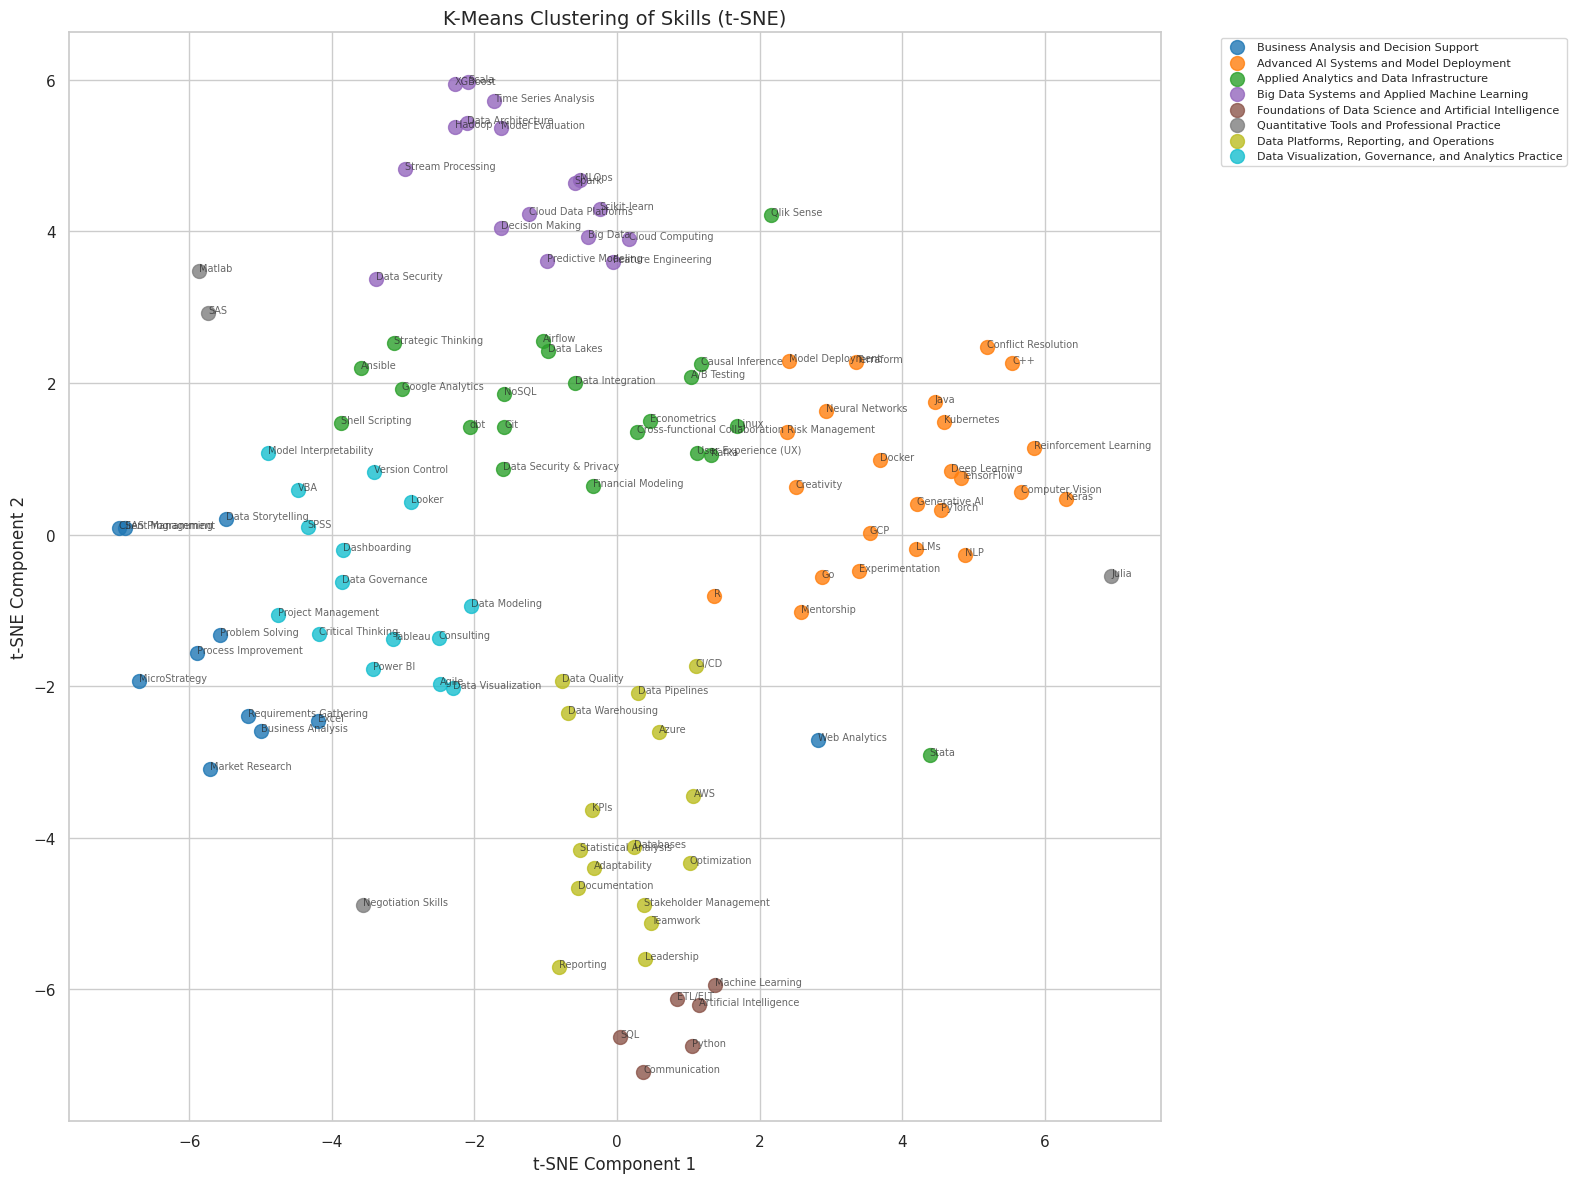

In [181]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
skill_tsne = tsne.fit_transform(skill_features_scaled)

# used adjusted labels
adjusted_labels = skill_features_adjusted['Course_Cluster'].values
skill_names = skill_features_scaled.index.tolist()

unique_clusters = sorted(np.unique(adjusted_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

fig, ax = plt.subplots(figsize=(16, 12))

for c, color in zip(unique_clusters, colors):
    mask = adjusted_labels == c
    indices = np.where(mask)[0]
    ax.scatter(
        skill_tsne[mask, 0],
        skill_tsne[mask, 1],
        label=kmeans_course_names[c],
        color=color,
        s=100,
        alpha=0.8
    )
    for i in indices:
        ax.annotate(
            skill_names[i],
            (skill_tsne[i, 0], skill_tsne[i, 1]),
            fontsize=7,
            alpha=0.7
        )

ax.set_title('K-Means Clustering of Skills (t-SNE)', fontsize=14)
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Develop an ensemble method

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from IPython.display import display, Markdown

# Build Consensus Matrix
# Both manual_labels (Hierarchical) and adjusted_labels (K-Means) should be length 114

n_skills = len(skill_columns)
hier_sim = np.zeros((n_skills, n_skills))
kmeans_sim = np.zeros((n_skills, n_skills))

# Both models now use the same 114 skills
for i in range(n_skills):
    for j in range(n_skills):
        if manual_labels[i] == manual_labels[j]:
            hier_sim[i, j] = 1.0
        if adjusted_labels[i] == adjusted_labels[j]:
            kmeans_sim[i, j] = 1.0

# Average of both models' votes
ensemble_sim = (hier_sim + kmeans_sim) / 2.0
ensemble_dist = 1.0 - ensemble_sim

# Ensure exact 0s on the diagonal
np.fill_diagonal(ensemble_dist, 0)

print(f"n_skills: {n_skills}")
print(f"manual_labels length: {len(manual_labels)}")
print(f"adjusted_labels length: {len(adjusted_labels)}")
print(f"ensemble_sim shape: {ensemble_sim.shape}")

n_skills: 114
manual_labels length: 114
adjusted_labels length: 114
ensemble_sim shape: (114, 114)


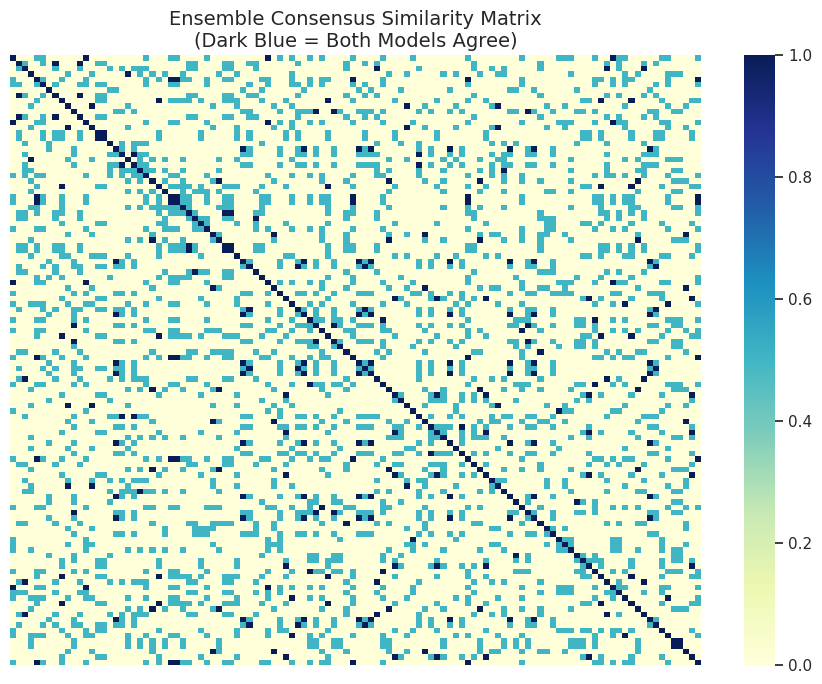

In [171]:
# Visualize the Consensus
plt.figure(figsize=(9, 7))
sns.heatmap(ensemble_sim, cmap='YlGnBu', xticklabels=False, yticklabels=False)
plt.title('Ensemble Consensus Similarity Matrix\n(Dark Blue = Both Models Agree)', fontsize=14)
plt.tight_layout()
plt.show()

In [172]:
#Final Agglomerative Clustering
condensed_ensemble_dist = squareform(ensemble_dist)
# 'complete' linkage enforces strict consensus
Z_ensemble = linkage(condensed_ensemble_dist, method='average')

FINAL_K = 9  # Number of final modules
ensemble_labels = fcluster(Z_ensemble, t=FINAL_K, criterion='maxclust')


print(f"Final Ensemble Curriculum ({FINAL_K} Modules)")

ensemble_courses = {}
for i, skill in enumerate(skill_columns):
    c = ensemble_labels[i]
    if c not in ensemble_courses:
        ensemble_courses[c] = []
    ensemble_courses[c].append(skill)

for c in sorted(ensemble_courses.keys()):
    skills = ensemble_courses[c]
    print(f"Module {c} ({len(skills)} skills):")
    print(', '.join(skills))

Final Ensemble Curriculum (9 Modules)
Module 1 (11 skills):
Business Analysis, Client Management, Data Storytelling, Excel, Market Research, MicroStrategy, Problem Solving, Process Improvement, Requirements Gathering, SAS Programming, Web Analytics
Module 2 (15 skills):
Agile, Consulting, Critical Thinking, Dashboarding, Data Governance, Data Modeling, Data Visualization, Looker, Model Interpretability, Power BI, Project Management, SPSS, Tableau, VBA, Version Control
Module 3 (13 skills):
Adaptability, Data Pipelines, Data Quality, Data Warehousing, Databases, Documentation, KPIs, Leadership, Optimization, Reporting, Stakeholder Management, Statistical Analysis, Teamwork
Module 4 (10 skills):
AWS, Ansible, Azure, CI/CD, Cloud Computing, Cloud Data Platforms, Docker, GCP, Kubernetes, Terraform
Module 5 (20 skills):
C++, Computer Vision, Conflict Resolution, Creativity, Deep Learning, Experimentation, Generative AI, Go, Java, Keras, LLMs, Mentorship, Model Deployment, NLP, Neural Networ

In [174]:
# Manual adjustments to ensemble results
ensemble_labels_adjusted = ensemble_labels.copy()

adjustments = {
    # Module 5: non-technical soft skills - Module 2 (soft/professional)
    'Conflict Resolution': 2,
    'Creativity': 2,
    'Mentorship': 2,

    # Module 5: Risk Management - Module 9 (technical/ML)
    'Risk Management': 9,

    # Module 6 too small and mixed: redistribute
    'Negotiation Skills': 1,  # - Module 1 (business)
    'Julia': 8,               # - Module 8 (core tools)
    'Matlab': 8,
    'SAS': 8,
}

for i, skill in enumerate(skill_columns):
    if skill in adjustments:
        ensemble_labels_adjusted[i] = adjustments[skill]

from sklearn.preprocessing import LabelEncoder
ensemble_labels_adjusted = LabelEncoder().fit_transform(ensemble_labels_adjusted)

# Build adjusted courses
ensemble_courses_adjusted = {}
for i, skill in enumerate(skill_columns):
    c = ensemble_labels_adjusted[i]
    if c not in ensemble_courses_adjusted:
        ensemble_courses_adjusted[c] = []
    ensemble_courses_adjusted[c].append(skill)

print("Final Ensemble Curriculum (after minimal adjustment):\n")
for c in sorted(ensemble_courses_adjusted.keys()):
    skills = ensemble_courses_adjusted[c]
    print(f"Module {c} ({len(skills)} skills):")
    print(', '.join(skills))
    print("-" * 50)

Final Ensemble Curriculum (after minimal adjustment):

Module 0 (12 skills):
Business Analysis, Client Management, Data Storytelling, Excel, Market Research, MicroStrategy, Negotiation Skills, Problem Solving, Process Improvement, Requirements Gathering, SAS Programming, Web Analytics
--------------------------------------------------
Module 1 (18 skills):
Agile, Conflict Resolution, Consulting, Creativity, Critical Thinking, Dashboarding, Data Governance, Data Modeling, Data Visualization, Looker, Mentorship, Model Interpretability, Power BI, Project Management, SPSS, Tableau, VBA, Version Control
--------------------------------------------------
Module 2 (13 skills):
Adaptability, Data Pipelines, Data Quality, Data Warehousing, Databases, Documentation, KPIs, Leadership, Optimization, Reporting, Stakeholder Management, Statistical Analysis, Teamwork
--------------------------------------------------
Module 3 (10 skills):
AWS, Ansible, Azure, CI/CD, Cloud Computing, Cloud Data Platfo

In [182]:
ensemble_course_names = {
    0: 'Business Analysis and Analytics Communication',
    1: 'Data Visualization, Governance, and Project Practice',
    2: 'Data Operations and Performance Analytics',
    3: 'Cloud and DevOps for Data Systems',
    4: 'Deep Learning and Intelligent Systems',
    5: 'Applied Analytics and Data Infrastructure',
    6: 'Foundations of Data Science and Artificial Intelligence',
    7: 'Machine Learning, Big Data, and Predictive Systems'
}

print("Final Ensemble Curriculum:\n")
for c in sorted(ensemble_courses_adjusted.keys()):
    skills = ensemble_courses_adjusted[c]
    print(f"{ensemble_course_names[c]} ({len(skills)} skills):")
    print(', '.join(skills))
    print("-" * 60)

# Verify
all_assigned = [s for skills in ensemble_courses_adjusted.values() for s in skills]
print(f"\nTotal assigned: {len(all_assigned)}")
print(f"Unique assigned: {len(set(all_assigned))}")
print(f"Total skills: {len(skill_columns)}")
missing = set(skill_columns) - set(all_assigned)
if missing:
    print(f"Missing: {missing}")
else:
    print("All skills covered")

Final Ensemble Curriculum:

Business Analysis and Analytics Communication (12 skills):
Business Analysis, Client Management, Data Storytelling, Excel, Market Research, MicroStrategy, Negotiation Skills, Problem Solving, Process Improvement, Requirements Gathering, SAS Programming, Web Analytics
------------------------------------------------------------
Data Visualization, Governance, and Project Practice (18 skills):
Agile, Conflict Resolution, Consulting, Creativity, Critical Thinking, Dashboarding, Data Governance, Data Modeling, Data Visualization, Looker, Mentorship, Model Interpretability, Power BI, Project Management, SPSS, Tableau, VBA, Version Control
------------------------------------------------------------
Data Operations and Performance Analytics (13 skills):
Adaptability, Data Pipelines, Data Quality, Data Warehousing, Databases, Documentation, KPIs, Leadership, Optimization, Reporting, Stakeholder Management, Statistical Analysis, Teamwork
----------------------------

# Models Comparison

In [208]:
# Comparison of three curricula

# Hierarchical
print(f"\nHierarchical Clustering: {len(manual_courses_h)} courses")
for course, skills in manual_courses_h.items():
    print(f"  {course} ({len(skills)} skills)")

# K-Means
print(f"\nK-Means Clustering: {len(kmeans_course_names)} courses")
for c, name in kmeans_course_names.items():
    skills = skill_features_adjusted[skill_features_adjusted['Course_Cluster'] == c].index.tolist()
    print(f"  {name} ({len(skills)} skills)")

# Ensemble
print(f"\nEnsemble Method: {len(ensemble_course_names)} courses")
for c in sorted(ensemble_courses_adjusted.keys()):
    skills = ensemble_courses_adjusted[c]
    print(f"  {ensemble_course_names[c]} ({len(skills)} skills)")


Hierarchical Clustering: 10 courses
  Programming Foundations for Data Science (13 skills)
  Data Engineering and Database Systems (16 skills)
  Data Visualization and Business Intelligence (13 skills)
  Statistical Analysis and Experimentation (11 skills)
  Machine Learning and Predictive Modeling (11 skills)
  Deep Learning and Applied AI (10 skills)
  Cloud and DevOps for Data Systems (10 skills)
  Data Governance, Security, and Quality (7 skills)
  Business Analysis and Strategy (11 skills)
  Professional Skills for Data Science and Analytics (12 skills)

K-Means Clustering: 8 courses
  Business Analysis and Decision Support (11 skills)
  Advanced AI Systems and Model Deployment (24 skills)
  Applied Analytics and Data Infrastructure (21 skills)
  Big Data Systems and Applied Machine Learning (17 skills)
  Foundations of Data Science and Artificial Intelligence (6 skills)
  Quantitative Tools and Professional Practice (4 skills)
  Data Platforms, Reporting, and Operations (16 skil

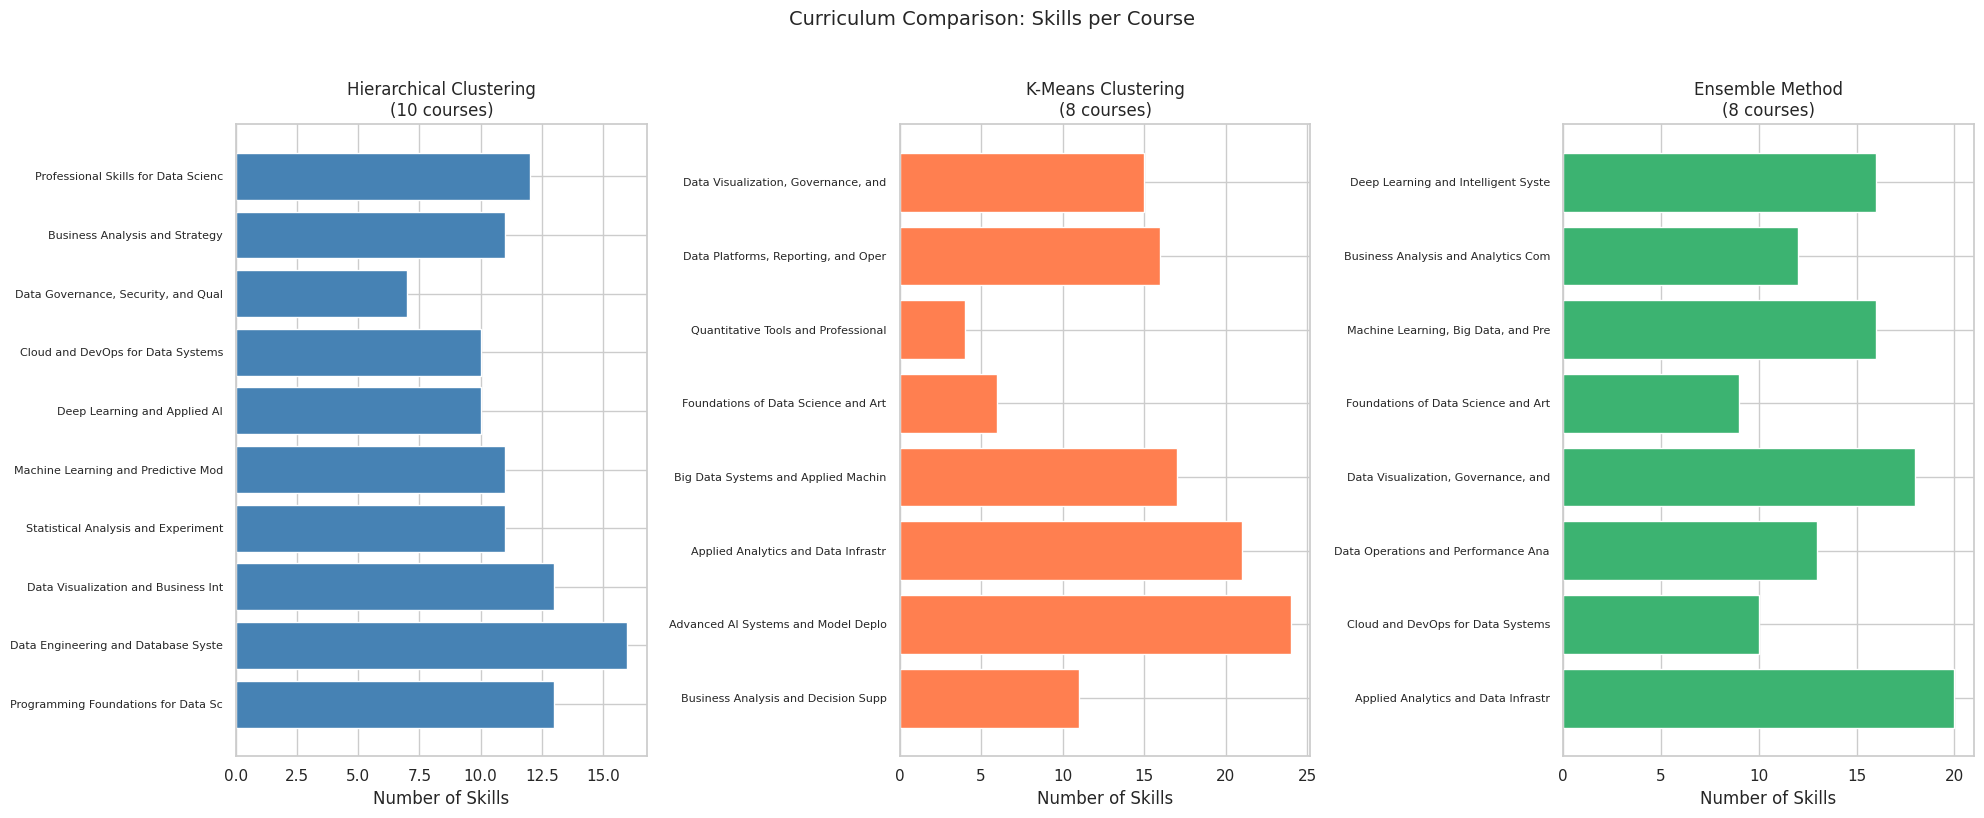

In [209]:
import matplotlib.pyplot as plt
import numpy as np

# Data for comparison
hier_courses = {course: len(skills) for course, skills in manual_courses_h.items()}
kmeans_courses = {kmeans_course_names[c]: len(skill_features_adjusted[skill_features_adjusted['Course_Cluster'] == c])
                  for c in sorted(skill_features_adjusted['Course_Cluster'].unique())}
ensemble_courses_named = {ensemble_course_names[c]: len(skills)
                          for c, skills in ensemble_courses_adjusted.items()}

n_hier = len(hier_courses)
n_kmeans = len(kmeans_courses)
n_ensemble = len(ensemble_courses_named)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Hierarchical
axes[0].barh(range(n_hier), list(hier_courses.values()), color='steelblue')
axes[0].set_yticks(range(n_hier))
axes[0].set_yticklabels([c[:35] for c in hier_courses.keys()], fontsize=8)
axes[0].set_title(f'Hierarchical Clustering\n({n_hier} courses)', fontsize=12)
axes[0].set_xlabel('Number of Skills')

# K-Means
axes[1].barh(range(n_kmeans), list(kmeans_courses.values()), color='coral')
axes[1].set_yticks(range(n_kmeans))
axes[1].set_yticklabels([c[:35] for c in kmeans_courses.keys()], fontsize=8)
axes[1].set_title(f'K-Means Clustering\n({n_kmeans} courses)', fontsize=12)
axes[1].set_xlabel('Number of Skills')

# Ensemble
axes[2].barh(range(n_ensemble), list(ensemble_courses_named.values()), color='mediumseagreen')
axes[2].set_yticks(range(n_ensemble))
axes[2].set_yticklabels([c[:35] for c in ensemble_courses_named.keys()], fontsize=8)
axes[2].set_title(f'Ensemble Method\n({n_ensemble} courses)', fontsize=12)
axes[2].set_xlabel('Number of Skills')

plt.suptitle('Curriculum Comparison: Skills per Course', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation of results using Gemini

In [194]:
import time
from IPython.display import display, Markdown

# Use hierarchical curriculum directly from memory
if 'manual_courses_h' in globals():
    hier_curriculum = {f"Course {i+1} - {name}": skills
                       for i, (name, skills) in enumerate(manual_courses_h.items())}
    print(f"Using hierarchical curriculum from memory ({len(hier_curriculum)} courses)")

# Prepare curriculum text
curriculum_text = "\n".join(
    f"- {course}: {', '.join(skills)}"
    for course, skills in hier_curriculum.items()
)

# Prompt 1: Program Description
prompt1 = f"""
You are a program director at University of Toronto.
Based on this data science master's curriculum, write a professional 150-word description to attract students.

Curriculum:
{curriculum_text}
""".strip()

if client:
    print("Calling Gemini API for Program Description...")
    time.sleep(2)

    try:
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=prompt1,
            config=types.GenerateContentConfig(
                temperature=0.7,
                max_output_tokens=2048,
            ),
        )

        if response.text:
            print(f"\nProgram Description ")
            print(response.text)
            print(f"\nResponse length: {len(response.text)} characters")
        else:
            print("No text returned.")

    except Exception as e:
        print(f"Error: {e}")

Using hierarchical curriculum from memory (10 courses)
Calling Gemini API for Program Description...

Program Description 
As Program Director for the University of Toronto's Master of Data Science, I invite you to explore a truly comprehensive and forward-thinking curriculum. Our program meticulously builds your expertise from foundational programming (Python, SQL, R, Java) and robust data engineering (Spark, Kafka, Airflow, dbt, cloud platforms like AWS, Azure, GCP) to cutting-edge machine learning and deep learning, including LLMs and Generative AI.

You will master advanced statistical analysis, A/B testing, data visualization, and business intelligence, transforming raw data into compelling narratives. Crucially, we integrate essential business analysis, strategic thinking, and professional skills—from communication and leadership to project management and ethical data governance. This holistic approach ensures you graduate not just as a technically proficient data scientist, but 

In [193]:
import time

# Prompt 2: Curriculum Validation
curriculum_text_p2 = "\n".join(
    f"- {course}: {', '.join(skills)}"
    for course, skills in hier_curriculum.items()
)

prompt2 = f"""
You are a Senior Data Science Hiring Manager.
Audit this University of Toronto Master's curriculum against current job market trends:

{curriculum_text_p2}

Please analyze:
1. Key Strengths
2. Skill Gaps
3. Overall Verdict

Keep it under 250 words.
""".strip()

if client:
    print("Calling Gemini API for Curriculum Validation...")
    time.sleep(10)

    try:
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=prompt2,
            config=types.GenerateContentConfig(
                temperature=0.7,
                max_output_tokens=2048,
            ),
        )

        if response.text:
            print("\nCurriculum Validation")
            print(response.text)
            print(f"\nResponse length: {len(response.text)} characters")
        else:
            print("No text returned.")

    except Exception as e:
        print(f"Error: {e}")

Calling Gemini API for Curriculum Validation...

Curriculum Validation
**1. Key Strengths:**
This curriculum is exceptionally robust and current. It covers the full spectrum of modern data science, from strong foundations in Python, SQL, Git, and Linux, through comprehensive data engineering (Airflow, dbt, Spark, Kafka), visualization (Tableau, Power BI), and advanced ML/DL (XGBoost, LLMs, Generative AI, MLOps). The multi-cloud exposure (AWS, Azure, GCP) and DevOps (Docker, Kubernetes) are critical. Crucially, the inclusion of Data Governance, Business Analysis, and Professional Skills (communication, leadership, project management) is outstanding, preparing graduates for real-world impact and senior roles.

**2. Skill Gaps:**
The primary concern is **Course 1's excessive list of programming languages**. Attempting to cover Python, SQL, R, Java, Scala, C++, Go, VBA, and Julia risks shallow understanding and wastes valuable time on languages not central to most modern DS roles. A sharpe

In [196]:
import time

# Prompt 3: Gap Analysis
curriculum_text_p3 = "\n".join(
    f"- {course}: {', '.join(skills)}"
    for course, skills in hier_curriculum.items()
)

prompt3 = f"""
You are a data science curriculum expert.
Review this Master's program curriculum and identify:
1. Important missing skills relative to current industry needs
2. Redundancies or overlapping content between courses
3. Over-emphasized areas that may not reflect current market demand

Curriculum:
{curriculum_text_p3}

Keep response under 300 words and be specific.
""".strip()

if client:
    print("Calling Gemini API for Gap Analysis...")
    time.sleep(10)

    try:
        response = client.models.generate_content(
            model=GEMINI_MODEL,
            contents=prompt3,
            config=types.GenerateContentConfig(
                temperature=0.7,
                max_output_tokens=4000,
            ),
        )

        if response.text:
            print("\nGap Analysis")
            print(response.text)
            print(f"\nResponse length: {len(response.text)} characters")
        else:
            print("No text returned.")

    except Exception as e:
        print(f"Error: {e}")

Calling Gemini API for Gap Analysis...

Gap Analysis
Here's a review of the Master's program curriculum:

1.  **Important Missing Skills:**
    *   **Software Engineering Best Practices:** Beyond basic Git, include robust testing (unit, integration), API development for data products, and advanced CI/CD for MLOps.
    *   **Responsible AI/Ethics:** Dedicated coverage of bias detection, fairness, transparency, and the ethical implications of AI models.
    *   **Vector Databases & RAG Architectures:** Essential for practical LLM applications, given the LLM emphasis in Course 6.
    *   **Prompt Engineering:** A crucial practical skill for interacting with and optimizing LLMs.

2.  **Redundancies/Overlapping Content:**
    *   **Course 1 - Programming Foundations:** The extensive list of languages (Java, Scala, C++, Go, VBA, Julia) is excessive. Python, SQL, and R are core; others dilute focus. Java/Scala could be introduced contextually within Course 2 (Spark).
    *   **Course 5 (Neura